# Notebook 3: TF-IDF Doctor Retriever
## Building a Medical Search Engine from Patient Reviews

---

In our Preprocessing notebook, we cleaned **66,465** patient comments into ~52,800 usable rows.

Now we build a **search engine**: given a medical query → return the most relevant doctors.

| Part | Topic |
|------|-------|
| **0** | Setup & Data Loading |
| **1** | TF-IDF Theory (from scratch) |
| **2** | Medical Stopwords Pipeline |
| **3** | Building the Doctor Corpus (baseline + medical) |
| **4** | Building the TF-IDF Index (both variants) |
| **5** | Query Preprocessing |
| **6** | Retrieval — Cosine Similarity Search |
| **7** | Recommendation-Aware Reranking |
| **8** | Holdout Evaluation (Recall@K, MRR) |
| **9** | Qualitative Test Suite |
| **10** | Interactive Search — Play With the Retriever 🎮 |
| **11** | Summary & Next Steps |

### Two Retriever Variants

| Variant | Stopwords Applied | Best For | Example Queries |
|---------|-------------------|----------|----------------|
| **Baseline** | Standard Persian only (hazm) | Service / behavioral queries | "با حوصله", "بد برخورد" |
| **Medical** | Standard + domain-specific | Clinical / diagnostic queries | "سنگ کلیه", "دیسک کمر" |

The medical variant removes praise ("عالی"), thanks ("ممنون"), clinic ops ("مطب", "نوبت"), and behavioral adjectives ("حوصله", "مهربان") — leaving only **clinical content**.

---
# Part 0: Setup & Data Loading
---

## What is Information Retrieval?

**Information Retrieval (IR)** is the science of finding, within a large collection of unstructured data (usually text), the items that satisfy a user's information need.

```
Google Search:   "kidney stone treatment"   →   Ranked list of web pages
Our System:      "سنگ کلیه"                 →   Ranked list of DOCTORS
```

This is fundamentally different from a database query:

- **Database:** Exact match — `WHERE specialty = 'urology'` returns only urologists, missing doctors whose patients frequently mention kidney stones but whose specialty label is "general surgery".
- **IR:** Semantic relevance — if 50 patients of Dr. X mention "سنگ کلیه" in their reviews, Dr. X is relevant to this query regardless of their listed specialty.

The core idea behind most IR systems: represent both queries and documents as **numerical vectors** in a shared space, then measure the **similarity** between them.

In [1]:
import re, os, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

tqdm.pandas(desc="Processing")
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print("All imports OK ✓")

All imports OK ✓


## Loading the Data

We load two files produced by our previous notebooks:

1. **Preprocessed comments** — each row is one patient review, already tokenized and cleaned (output of our Preprocessing notebook).
2. **Doctor metadata** — name, specialty, profile URL (from our EDA notebook).

The key column is `final_preprocessed_text`: a space-separated string of tokens, with standard Persian stopwords already removed and Arabic characters normalized to Persian.

In [2]:
comments_df = pd.read_csv("comments_for_tfidf_retriever.csv", keep_default_na=False)
comments_df["doctor_id"] = comments_df["doctor_id"].astype(str)
comments_df["final_preprocessed_text"] = comments_df["final_preprocessed_text"].astype(str)
print(f"Loaded {len(comments_df):,} comments | {comments_df['doctor_id'].nunique():,} doctors")
comments_df.head(3)

Loaded 66,464 comments | 545 doctors


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False


In [3]:
doctors_df = pd.read_csv("doctors_raw_canonical.csv", keep_default_na=False)
doctors_df["doctor_id"] = doctors_df["doctor_id"].astype(str)
name_map = dict(zip(doctors_df["doctor_id"], doctors_df.get("name", ""))) if "name" in doctors_df.columns else {}
specialty_map = dict(zip(doctors_df["doctor_id"], doctors_df.get("specialty", ""))) if "specialty" in doctors_df.columns else {}
print(f"Loaded {len(doctors_df):,} doctor profiles")

Loaded 569 doctor profiles


---
# Part 1: Understanding TF-IDF (from scratch)
---

**TF-IDF** (Term Frequency – Inverse Document Frequency) is one of the most fundamental and widely-used text representation methods in information retrieval. Despite being introduced in the 1970s, it remains a strong baseline that often outperforms more complex methods on small-to-medium corpora.

In this part, we will:
1. Compute TF-IDF **manually** on a tiny 4-sentence corpus
2. Understand **why** each component exists
3. Verify our manual results match `sklearn`

## 1.1 The Core Problem: Representing Text as Numbers

Machine learning algorithms operate on numbers, not words. We need a function:

$$f: \text{"سنگ کلیه عمل درد"} \longrightarrow [0.42, 0.0, 0.31, \ldots] \in \mathbb{R}^{|V|}$$

where $|V|$ is the vocabulary size. Each dimension corresponds to one word (or phrase), and the value encodes how **important** that word is to this document.

**Example:** Query is "سنگ کلیه" (kidney stones).

| Doctor | Comments | Relevance |
|--------|----------|-----------|
| A | سنگ کلیه عمل درد | ✅ High — shares both query terms |
| B | سنگ مثانه درمان | ⚠️ Partial — shares "سنگ" only |
| C | دکتر خوب عالی | ❌ None — no medical overlap |

TF-IDF is a specific instantiation of this function. Let's build it step by step.

## 1.2 Term Frequency (TF)

The simplest idea: **count how often each word appears** in a document.

$$\text{TF}(t, d) = \text{count of term } t \text{ in document } d$$

If "سنگ" appears 5 times in Doctor A's reviews and 1 time in Doctor B's, Doctor A's document has a higher TF for that term — suggesting stronger association with kidney stones.

In [4]:
# Let's build a tiny corpus and compute TF manually
corpus = [
    "سنگ کلیه درد سنگ",    # Doc 0: kidney stone + pain ("سنگ" appears twice)
    "سنگ مثانه درمان",      # Doc 1: bladder stone treatment
    "دکتر خوب عالی",        # Doc 2: irrelevant praise
    "درد کمر دیسک درد",     # Doc 3: back pain + disc ("درد" appears twice)
]

tokenized = [doc.split() for doc in corpus]
vocab = sorted(set(w for doc in tokenized for w in doc))

tf_matrix = [[Counter(doc).get(t, 0) for t in vocab] for doc in tokenized]
tf_df = pd.DataFrame(tf_matrix, columns=vocab, index=[f"Doc {i}" for i in range(len(corpus))])
print(f"Vocabulary ({len(vocab)} unique terms):\n")
tf_df

Vocabulary (10 unique terms):



,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0,1,0,0,0,2,0,0,1,0
Doc 1,0,0,1,0,0,1,0,1,0,0
Doc 2,1,0,0,1,0,0,1,0,0,0
Doc 3,0,2,0,0,1,0,0,0,0,1


### The Problem with Raw TF

Raw term frequency has two fundamental weaknesses:

1. **Document length bias:** A doctor with 500 comments will have higher TF for *every* word compared to a doctor with 5 comments — not because they're more relevant, but simply because there's more text.

2. **No discrimination between common and rare words:** The word "درد" (pain) might appear in almost every doctor's reviews, while "کلیه" (kidney) only appears in a few. Raw TF treats them equally, but "کلیه" is far more informative for distinguishing doctors.

We need a mechanism to **down-weight common words** and **up-weight rare, discriminative words**. That's where IDF comes in.

## 1.3 Inverse Document Frequency (IDF)

IDF measures how **informative** a term is across the entire corpus. The intuition: a word that appears in *every* document carries no information for distinguishing between them.

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1$$

Where:
- $N$ = total number of documents in the corpus
- $\text{df}(t)$ = **document frequency** — number of documents containing term $t$

**Key insight:** The logarithm ensures that IDF grows slowly. A term appearing in 1 out of 1000 documents doesn't get 1000× the weight of a term appearing in every document — the log compresses this to a manageable scale.

The `+1` additions serve as **smoothing**: the one inside the fraction prevents division by zero; the one outside prevents IDF from ever being zero (every term gets at least some weight).

> 📝 This is sklearn's default "smooth IDF" formula. Other variants exist (e.g., standard IDF without the +1 additions), but this one is most robust in practice.

In [5]:
N = len(corpus)
doc_freq = {t: sum(1 for doc in tokenized if t in doc) for t in vocab}
idf_values = {t: round(np.log((1 + N) / (1 + doc_freq[t])) + 1, 4) for t in vocab}

print(pd.DataFrame({"df (in how many docs?)": doc_freq, "IDF": idf_values}).to_string())

print(f"\n→ Most informative:  '{max(idf_values, key=idf_values.get)}' — appears in fewest docs")
print(f"→ Least informative: '{min(idf_values, key=idf_values.get)}' — appears in most docs")

       df (in how many docs?)     IDF
خوب                         1  1.9163
درد                         2  1.5108
درمان                       1  1.9163
دکتر                        1  1.9163
دیسک                        1  1.9163
سنگ                         2  1.5108
عالی                        1  1.9163
مثانه                       1  1.9163
کلیه                        1  1.9163
کمر                         1  1.9163

→ Most informative:  'خوب' — appears in fewest docs
→ Least informative: 'درد' — appears in most docs


## 1.4 TF × IDF: The Complete Picture

Now we combine both signals by multiplying them:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

This produces a **weighted** term-document matrix where:
- **Rare, relevant terms** (high TF in this doc, high IDF globally) → **high** score
- **Common, uninformative terms** (high TF, but low IDF) → **moderate** score
- **Absent terms** → **zero**

In [6]:
tfidf_matrix = []
for doc in tokenized:
    c = Counter(doc)
    tfidf_matrix.append([round(c.get(t, 0) * idf_values[t], 4) for t in vocab])

tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab, index=[f"Doc {i}" for i in range(len(corpus))])
print("TF-IDF Matrix (before normalization):")
tfidf_df

TF-IDF Matrix (before normalization):


,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,1.5108,0.0000,0.0000,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000
Doc 1,0.0000,0.0000,1.9163,0.0000,0.0000,1.5108,0.0000,1.9163,0.0000,0.0000
Doc 2,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000
Doc 3,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000,0.0000,1.9163


### 🔬 Interactive TF-IDF Explorer

We just built TF, IDF, and TF-IDF matrices. Now let's **play** with them.

The CLI below lets you:
- Type a **term** → see its TF in each document, IDF weight, and TF-IDF breakdown with a bar chart
- Type `all` → see the full colored heatmap
- Type `list` → see all available terms
- Type `exit` → move on

  🔬 TF-IDF Explorer — Toy Corpus (4 documents)
  Commands: type a term | "all" | "list" | "exit"
  Doc 0: سنگ کلیه درد سنگ
  Doc 1: سنگ مثانه درمان
  Doc 2: دکتر خوب عالی
  Doc 3: درد کمر دیسک درد



🔍 Term>  list


  Available terms: ['خوب', 'درد', 'درمان', 'دکتر', 'دیسک', 'سنگ', 'عالی', 'مثانه', 'کلیه', 'کمر']


🔍 Term>  عالی



  ──────────────────────────────────────────────────
  📊 Term: 'عالی'
  ├─ Appears in: 1/4 documents
  ├─ IDF weight: 1.9163
  ├─ Formula: log((1+4)/(1+1)) + 1 = 1.9163
  └─ Per-document:
     Doc 0 [سنگ کلیه درد سنگ    ]  TF=0  ×  IDF=1.9163  =  0.0000  ·
     Doc 1 [سنگ مثانه درمان     ]  TF=0  ×  IDF=1.9163  =  0.0000  ·
     Doc 2 [دکتر خوب عالی       ]  TF=1  ×  IDF=1.9163  =  1.9163  █████████
     Doc 3 [درد کمر دیسک درد    ]  TF=0  ×  IDF=1.9163  =  0.0000  ·


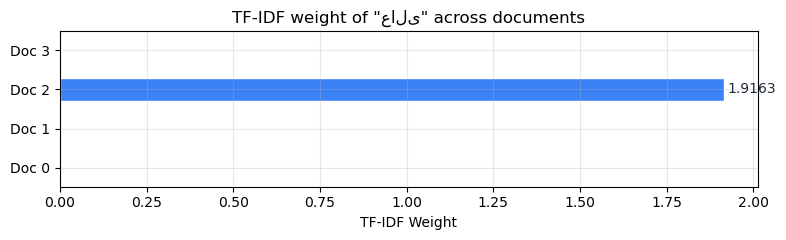

🔍 Term>  سنگ



  ──────────────────────────────────────────────────
  📊 Term: 'سنگ'
  ├─ Appears in: 2/4 documents
  ├─ IDF weight: 1.5108
  ├─ Formula: log((1+4)/(1+2)) + 1 = 1.5108
  └─ Per-document:
     Doc 0 [سنگ کلیه درد سنگ    ]  TF=2  ×  IDF=1.5108  =  3.0216  ███████████████
     Doc 1 [سنگ مثانه درمان     ]  TF=1  ×  IDF=1.5108  =  1.5108  ███████
     Doc 2 [دکتر خوب عالی       ]  TF=0  ×  IDF=1.5108  =  0.0000  ·
     Doc 3 [درد کمر دیسک درد    ]  TF=0  ×  IDF=1.5108  =  0.0000  ·


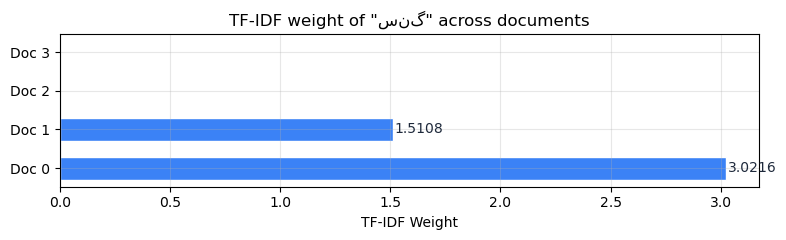


Done.


In [7]:
# --- Interactive TF-IDF Explorer ---

def show_heatmap(matrix_df, title):
    """Display a colored heatmap using pandas.style."""
    display(matrix_df.style
            .background_gradient(cmap='Blues', axis=None)
            .format('{:.4f}')
            .set_caption(title))

def explore_term_detail(term):
    """Show detailed TF/IDF/TF-IDF breakdown for one term with bar chart."""
    if term not in vocab:
        print(f"  ❌ '{term}' not found. Type 'list' to see available terms.")
        return
    
    df_count = sum(1 for doc in tokenized if term in doc)
    idf = idf_values[term]
    
    print(f"\n  {'─'*50}")
    print(f"  📊 Term: '{term}'")
    print(f"  ├─ Appears in: {df_count}/{len(corpus)} documents")
    print(f"  ├─ IDF weight: {idf:.4f}")
    print(f"  ├─ Formula: log((1+{len(corpus)})/(1+{df_count})) + 1 = {idf:.4f}")
    print(f"  └─ Per-document:")
    
    tfidf_vals = []
    for i, doc in enumerate(tokenized):
        tf = Counter(doc).get(term, 0)
        w = round(tf * idf, 4)
        tfidf_vals.append(w)
        bar = '█' * max(1, int(w * 5)) if w > 0 else '·'
        print(f"     Doc {i} [{corpus[i]:<20}]  TF={tf}  ×  IDF={idf:.4f}  =  {w:.4f}  {bar}")
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 2.5))
    colors = ['#3b82f6' if v > 0 else '#e2e8f0' for v in tfidf_vals]
    bars = ax.barh([f'Doc {i}' for i in range(len(corpus))], tfidf_vals, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('TF-IDF Weight')
    ax.set_title(f'TF-IDF weight of "{term}" across documents')
    for bar, val in zip(bars, tfidf_vals):
        if val > 0:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=10, color='#1e293b')
    plt.tight_layout()
    plt.show()

# --- CLI loop ---
print('=' * 55)
print('  🔬 TF-IDF Explorer — Toy Corpus (4 documents)')
print('  Commands: type a term | "all" | "list" | "exit"')
print('=' * 55)

# Show the corpus first
for i, doc in enumerate(corpus):
    print(f'  Doc {i}: {doc}')
print()

while True:
    try:
        cmd = input('🔍 Term> ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\nDone.'); break
    
    if cmd.lower() in {'exit', 'quit', 'q', ''}:
        print('Done.'); break
    elif cmd.lower() == 'list':
        print(f'  Available terms: {vocab}')
    elif cmd.lower() == 'all':
        print('\n  📋 TF Matrix:')
        show_heatmap(tf_df, 'Term Frequency (raw count)')
        print('\n  📋 TF-IDF Matrix:')
        show_heatmap(tfidf_df, 'TF × IDF')
    else:
        explore_term_detail(cmd)

## 1.5 Sublinear TF: Taming Frequency with Logarithms

There's a deeper problem with raw TF: the relationship between term frequency and relevance is **not linear**.

If "سنگ" appears **100 times** in one doctor's reviews and **10 times** in another's, is the first doctor **10× more relevant** to kidney stones? Almost certainly not. The first occurrence of a word is highly informative; subsequent occurrences provide diminishing returns.

**Sublinear TF** fixes this by applying a logarithmic compression:

$$\text{tf}_{\text{sub}}(t,d) = \begin{cases} 1 + \log(\text{tf}(t,d)) & \text{if tf} > 0 \\ 0 & \text{otherwise} \end{cases}$$

This dramatically compresses high counts:

| Raw TF | Sublinear TF | Compression Ratio |
|--------|-------------|-------------------|
| 1 | 1.00 | 1.0× |
| 10 | 3.30 | 3.3× (not 10×) |
| 100 | 5.61 | 5.6× (not 100×) |
| 1000 | 7.91 | 7.9× (not 1000×) |

This is particularly important for our use case: some doctors have hundreds of comments while others have only a handful. Without sublinear TF, prolific doctors would dominate search results regardless of relevance.

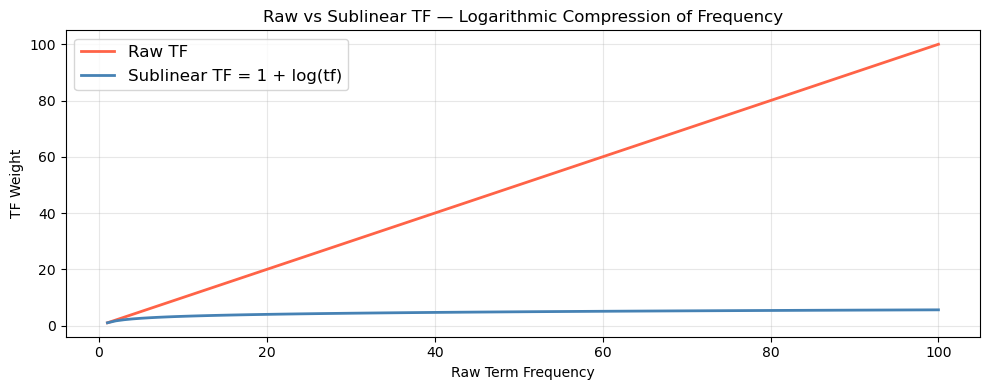

In [8]:
tf_vals = np.arange(1, 101)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tf_vals, tf_vals.astype(float), label="Raw TF", lw=2, color="tomato")
ax.plot(tf_vals, 1 + np.log(tf_vals), label="Sublinear TF = 1 + log(tf)", lw=2, color="steelblue")
ax.set_xlabel("Raw Term Frequency"); ax.set_ylabel("TF Weight")
ax.set_title("Raw vs Sublinear TF — Logarithmic Compression of Frequency")
ax.legend(fontsize=12); plt.tight_layout(); plt.show()

## 1.6 L2 Normalization and Cosine Similarity

### The Length Problem

Even with sublinear TF, longer documents will tend to have larger vector magnitudes simply because they contain more words. We need to normalize vectors so that **direction** (what the document is about) matters, not **magnitude** (how long it is).

**L2 Normalization** scales each document vector to unit length:

$$\hat{v} = \frac{v}{\|v\|_2} = \frac{v}{\sqrt{\sum_i v_i^2}}$$

After this, every vector lies on the unit hypersphere ($\|\hat{v}\| = 1$).

### Cosine Similarity

With unit vectors, **cosine similarity** reduces to a simple **dot product**:

$$\text{cos\_sim}(q, d) = \frac{q \cdot d}{\|q\| \cdot \|d\|} = q \cdot d \quad \text{(when both are L2-normalized)}$$

Properties:
- **1.0** = identical direction (maximum similarity)
- **0.0** = orthogonal (no shared terms at all)
- Negative values cannot occur with TF-IDF (all components ≥ 0)

**Why cosine over Euclidean distance?** Euclidean distance is dominated by vector magnitude — a long document far from a short one simply because it has more words. Cosine similarity ignores magnitude and focuses purely on the **angle** (i.e., the *proportion* of terms), which is what we care about.

In [9]:
# L2-normalize the TF-IDF matrix
tfidf_arr = tfidf_df.values.astype(float)
l2 = np.sqrt(np.sum(tfidf_arr ** 2, axis=1, keepdims=True))
l2[l2 == 0] = 1.0
tfidf_normed = tfidf_arr / l2

# Build and normalize a query vector for "سنگ کلیه"
query = "سنگ کلیه"
q_c = Counter(query.split())
q_vec = np.array([q_c.get(t, 0) * idf_values[t] for t in vocab])
q_vec = q_vec / (np.linalg.norm(q_vec) or 1.0)

# Compute cosine similarity (= dot product since both are normalized)
print(f"Query: '{query}'\n")
similarities = []
for i in range(len(corpus)):
    sim = np.dot(q_vec, tfidf_normed[i])
    similarities.append(sim)
    tag = "✅ Relevant" if sim > 0.3 else ("⚠️ Partial" if sim > 0.1 else "❌ Irrelevant")
    print(f"  Doc {i}: {corpus[i]:<25} sim={sim:.4f}  {tag}")

ranked = sorted(enumerate(similarities), key=lambda x: -x[1])
print(f"\n→ Ranking: {' > '.join(f'Doc {i} ({s:.3f})' for i, s in ranked)}")

Query: 'سنگ کلیه'

  Doc 0: سنگ کلیه درد سنگ          sim=0.8691  ✅ Relevant
  Doc 1: سنگ مثانه درمان           sim=0.3015  ✅ Relevant
  Doc 2: دکتر خوب عالی             sim=0.0000  ❌ Irrelevant
  Doc 3: درد کمر دیسک درد          sim=0.0000  ❌ Irrelevant

→ Ranking: Doc 0 (0.869) > Doc 1 (0.301) > Doc 2 (0.000) > Doc 3 (0.000)


## 1.7 Verification: Our Math = sklearn

Let's confirm that sklearn's `TfidfVectorizer` produces the **exact same results** as our manual computation. This builds confidence that we understand the algorithm correctly before applying it to real data.

In [10]:
vec_demo = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None,
                           lowercase=False, norm="l2", sublinear_tf=False)
X_demo = vec_demo.fit_transform(corpus)
sims_sk = cosine_similarity(vec_demo.transform([query]), X_demo).ravel()

print(f"Query: '{query}'\n")
for i, (m, s) in enumerate(zip(similarities, sims_sk)):
    print(f"  Doc {i}: manual={m:.4f}  sklearn={s:.4f}  {'✓ Match' if abs(m-s)<0.01 else '✗ Mismatch'}")

Query: 'سنگ کلیه'

  Doc 0: manual=0.8691  sklearn=0.8691  ✓ Match
  Doc 1: manual=0.3015  sklearn=0.3015  ✓ Match
  Doc 2: manual=0.0000  sklearn=0.0000  ✓ Match
  Doc 3: manual=0.0000  sklearn=0.0000  ✓ Match


## 1.8 N-grams: Capturing Multi-Word Medical Phrases

With unigrams only, the query "سنگ کلیه" (kidney stone) is decomposed into two independent terms: "سنگ" and "کلیه". This means a document about "سنگ صفرا" (gallstone) would score similarly to one about "سنگ کلیه", because both contain "سنگ".

By adding **bigrams** (`ngram_range=(1,2)`), we create features like:
- Unigrams: `سنگ`, `کلیه`, `صفرا`, ...
- Bigrams: `سنگ کلیه`, `سنگ صفرا`, ...

Now "سنگ کلیه" is a **single feature** with its own IDF weight, and a document about gallstones won't match it.

This is particularly important in medical text where **multi-word terms** carry specific meanings: "سنگ کلیه" ≠ "سنگ مثانه" ≠ "سنگ صفرا".

In [11]:
c_bi = ["سنگ کلیه درد شدید", "سنگ صفرا درمان", "کلیه پیوند عمل"]
v1 = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, ngram_range=(1,1), norm="l2", sublinear_tf=True)
v2 = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, ngram_range=(1,2), norm="l2", sublinear_tf=True)

s1 = cosine_similarity(v1.fit_transform(c_bi), v1.transform(["سنگ کلیه"])).ravel()
s2 = cosine_similarity(v2.fit_transform(c_bi), v2.transform(["سنگ کلیه"])).ravel()

print(f"Query: 'سنگ کلیه'\n")
for i, d in enumerate(c_bi):
    delta = "↑" if s2[i] > s1[i] + 0.01 else ("↓" if s2[i] < s1[i] - 0.01 else "=")
    print(f"  {d:<25}  Unigram={s1[i]:.4f}  Bigram={s2[i]:.4f}  {delta}")
print(f"\n→ Bigram features created: {sorted(v2.get_feature_names_out())}")

Query: 'سنگ کلیه'

  سنگ کلیه درد شدید          Unigram=0.6053  Bigram=0.5919  ↓
  سنگ صفرا درمان             Unigram=0.3349  Bigram=0.1841  ↓
  کلیه پیوند عمل             Unigram=0.3349  Bigram=0.1841  ↓

→ Bigram features created: ['درد', 'درد شدید', 'درمان', 'سنگ', 'سنگ صفرا', 'سنگ کلیه', 'شدید', 'صفرا', 'صفرا درمان', 'عمل', 'پیوند', 'پیوند عمل', 'کلیه', 'کلیه درد', 'کلیه پیوند']


---
# Part 2: Medical Stopwords Pipeline
---

## Why Domain-Specific Stopwords?

Our Preprocessing notebook already removed **standard Persian stopwords** (از، به، که، در، ...). But in a medical review corpus, a new class of "noise words" emerges:

- **"عالی"** (excellent) appears in 15,000+ reviews — it tells us nothing about *what* the doctor treats.
- **"دکتر"** (doctor) appears in virtually every review.
- **"مطب"** (office), **"نوبت"** (appointment) — service terms, not diagnostic.

If we leave these in, our TF-IDF index will be dominated by sentiment and service vocabulary. A query for "سنگ کلیه" might retrieve doctors who have many reviews saying "عالی" rather than doctors whose patients actually discuss kidney stones.

### The Three-Layer Architecture

We can't just blindly remove high-frequency words — some of them are medically critical ("درد" appears everywhere but is essential for pain-related queries). Our system has three layers:

```
Layer 1: SEED (Manual)         ~60 words curated by domain knowledge
Layer 2: AUTO-DISCOVERY        Data-driven: doc_ratio > 0.6 AND entropy > 0.6
Layer 3: SAFETY GUARDS         HIGH_RISK_KEEP + ALLOWLIST_LATIN → never removed
```

## 2.1 Layer 1: Manual Seed Stopwords

These words were identified through manual analysis of the corpus (in our EDA notebook) and grouped into semantic categories:

| Category | Examples | Why remove? |
|----------|---------|-------------|
| **Praise** | عالی, خوب, بهترین, محشر | Appear in ~80% of positive reviews — zero diagnostic signal |
| **Thanks** | مرسی, ممنون, تشکر, سپاس | Courtesy language, uniform across specialties |
| **Doctor addressing** | دکتر, پزشک, خانم, آقا | Present in virtually every review |
| **Clinic operations** | مطب, منشی, نوبت, هزینه, ویزیت | Service-related, not diagnostic |
| **Behavioral adjectives** | حوصله, اخلاق, مهربان, دلسوز | Behavioral — shared across all specialties |
| **Fillers** | سلام, واقعا, مراجعه | No semantic content for retrieval |

In [12]:
MEDICAL_STOPWORDS_SEED = {
    # praise
    "عالی", "خوب", "بهترین", "فوقالعاده", "محشر", "بینظیر", "راضی", "رضایت", "ناراضی",
    # thanks
    "مرسی", "ممنون", "تشکر", "سپاس", "قدردانی",
    # doctor address
    "دکتر", "پزشک", "خانم", "آقا", "آقای", "جناب", "ایشون", "ایشان",
    # clinic operations
    "مطب", "منشی", "پرسنل", "پذیرش", "نوبت", "نوبتدهی", "وقت", "معطلی",
    "شلوغ", "شلوغی", "هزینه", "ویزیت", "پرداخت", "کارت", "بیمه",
    "تومان", "تومن", "خدمات", "برخورد", "پاسخگو",
    # behavioral adjectives
    "حوصله", "اخلاق", "حاذق", "مودب", "محترم", "مهربان", "دلسوز", "صبور", "دقیق", "خوشبرخورد",
    # fillers
    "سلام", "درود", "واقعا", "فعلا", "مراجعه", "نتیجه", "هستم", "هستن", "هستند", "داشتم", "بودم", "بودن",
}
print(f"Seed stopwords: {len(MEDICAL_STOPWORDS_SEED)} words")

Seed stopwords: 64 words


## 2.2 Bigram Stopwords: Phrase-Level Removal

Some praise phrases consist of two words where **each word individually has legitimate medical uses**:

| Bigram to Remove | As Praise | Individual Medical Uses |
|-----------------|-----------|------------------------|
| "فوق" + "العاده" | "فوق‌العاده" = extraordinary | "فوق تخصص" = super-specialist |
| "بی" + "نظیر" | "بی‌نظیر" = unparalleled | "بی‌اختیاری" = incontinence, "بی‌حسی" = anesthesia |

The solution: only remove these words **when they appear together** as a pair.

In [13]:
MEDICAL_STOPWORD_BIGRAMS = {("فوق", "العاده"), ("بی", "نظیر")}
print(f"Bigram stopwords: {len(MEDICAL_STOPWORD_BIGRAMS)} pairs")

Bigram stopwords: 2 pairs


## 2.3 Layer 3: Safety Guards — Never Remove These

Some words appear in many documents (high df) but are **medically critical**. Our auto-discovery algorithm might flag them as stopword candidates, so we need explicit protection.

**HIGH_RISK_KEEP** — clinically essential terms:
- **درد** (pain) — the core of most patient queries
- **درمان** (treatment), **تشخیص** (diagnosis), **دارو** (medication)
- **عمل** (surgery), **جراحی** (surgical)
- **بی** — component of بی‌اختیاری (incontinence), بی‌حسی (anesthesia)
- **فوق** — component of فوق‌تخصص (super-specialist)

**ALLOWLIST_LATIN** — Latin medical acronyms that must always survive:
- Imaging: `mri`, `ct`
- Ligaments: `acl`, `mcl`, `pcl`
- Fertility: `ivf`, `iui`
- Urology: `pcnl`, `rirs`, `tul`
- Vertebrae: `l5`, `s1`, `t12`

In [14]:
HIGH_RISK_KEEP = {"درد", "دارو", "درمان", "تشخیص", "عمل", "جراحی", "بی", "فوق"}
MEDICAL_ALLOWLIST_LATIN = {
    "acl", "mcl", "pcl", "mri", "ct", "prp", "hpv", "psa",
    "ivf", "iui", "pcnl", "rirs", "tul", "l5", "s1", "t12", "ms", "avm", "co2",
}

# Build effective set = seed MINUS safety guards
def norm_tok(t):
    return str(t).strip().lower().replace("\u200c", "")

effective_medical_sw = {norm_tok(x) for x in MEDICAL_STOPWORDS_SEED if norm_tok(x)}
effective_medical_sw -= HIGH_RISK_KEEP | MEDICAL_ALLOWLIST_LATIN | {t for t in effective_medical_sw if len(t) < 2}
print(f"Seed: {len(MEDICAL_STOPWORDS_SEED)} → Effective (after safety filter): {len(effective_medical_sw)}")

Seed: 64 → Effective (after safety filter): 64


## 2.4 The Filter Function

The filter processes each token sequentially with **three priority rules** (checked in order):

1. **Latin allowlist** → always KEEP (e.g., MRI, HPV)
2. **Bigram check** → if current + next token form a stopword pair, REMOVE both
3. **Unigram check** → if token is in the stopword set, REMOVE
4. **Default** → KEEP

In [15]:
def filter_medical_stopwords(text, stopwords, allowlist_latin=None, bigrams=None):
    """Remove medical stopwords from space-tokenized text.
    Returns: (filtered_text, list_of_removed_tokens)
    """
    allowlist_latin = allowlist_latin or set()
    bigrams = bigrams or set()
    toks = str(text).split()
    kept, removed = [], []
    i = 0
    while i < len(toks):
        t1 = norm_tok(toks[i])
        if t1 in allowlist_latin:                                               # Rule 1
            kept.append(toks[i]); i += 1; continue
        if i+1 < len(toks) and (t1, norm_tok(toks[i+1])) in bigrams:           # Rule 2
            removed.extend([t1, norm_tok(toks[i+1])]); i += 2; continue
        if t1 in stopwords:                                                     # Rule 3
            removed.append(t1); i += 1; continue
        kept.append(toks[i]); i += 1                                            # Default
    return " ".join(kept), removed

# --- Demo ---
demo = "دکتر بسیار عالی بود برای درد کمر و mri رفتم فوق العاده بود"
filt, rem = filter_medical_stopwords(demo, effective_medical_sw, MEDICAL_ALLOWLIST_LATIN, MEDICAL_STOPWORD_BIGRAMS)
print(f"Input:   {demo}")
print(f"Output:  {filt}")
print(f"Removed: {rem}")
print(f"\n→ Notice: 'درد', 'کمر', 'mri' survived. 'دکتر', 'عالی', 'فوق العاده' removed.")

Input:   دکتر بسیار عالی بود برای درد کمر و mri رفتم فوق العاده بود
Output:  بسیار بود برای درد کمر و mri رفتم بود
Removed: ['دکتر', 'عالی', 'فوق', 'العاده']

→ Notice: 'درد', 'کمر', 'mri' survived. 'دکتر', 'عالی', 'فوق العاده' removed.


## 2.5 Applying the Filter: Creating Two Text Variants

We now have everything to create our two retriever inputs:
- **`text_baseline`** = `final_preprocessed_text` (standard stopwords only — from Preprocessing notebook)
- **`text_medical`** = baseline + medical stopword filter applied on top

In [16]:
comments_df["text_baseline"] = comments_df["final_preprocessed_text"]
comments_df["text_medical"] = comments_df["text_baseline"].progress_apply(
    lambda t: filter_medical_stopwords(t, effective_medical_sw, MEDICAL_ALLOWLIST_LATIN, MEDICAL_STOPWORD_BIGRAMS)[0]
)

n_empty = (comments_df["text_medical"].str.strip() == "").sum()
print(f"Medical texts empty after filter: {n_empty:,} ({n_empty/len(comments_df)*100:.1f}%)")

Processing: 100%|██████████| 66464/66464 [00:00<00:00, 136480.87it/s]

Medical texts empty after filter: 9,950 (15.0%)


---
# Part 3: Building the Doctor-Level Corpus
---

## Why Doctor-Level Documents?

Our retrieval target is a **doctor**, not an individual comment. A single comment might be very short ("خوب بود" — 2 tokens), but the *aggregate* of all comments for a doctor paints a rich picture of their practice.

By concatenating all comments per doctor into a single document, we achieve:
1. **Richer vocabulary** — specialized terms that appear in only a few comments still end up in the doctor's document
2. **Better TF-IDF performance** — the algorithm works better on longer documents where term distributions are more stable
3. **Direct retrieval** — cosine similarity directly produces a doctor ranking

In [17]:
def build_doctor_documents(df, text_col):
    """Concatenate all comments per doctor into a single document."""
    valid = df[df[text_col].str.strip() != ""].copy()
    docs = (valid.groupby("doctor_id")[text_col]
            .apply(lambda x: " ".join(x)).reset_index()
            .rename(columns={text_col: "document"}))
    docs["n_comments"] = valid.groupby("doctor_id").size().values
    docs["n_tokens"] = docs["document"].str.split().str.len()
    return docs

dd_baseline = build_doctor_documents(comments_df, "text_baseline")
dd_medical = build_doctor_documents(comments_df, "text_medical")
print(f"Baseline: {len(dd_baseline):,} doctors | Medical: {len(dd_medical):,} doctors")

Baseline: 545 doctors | Medical: 543 doctors


Total tokens — Baseline: 309,975 | Medical: 228,383 | Reduction: 26.3%


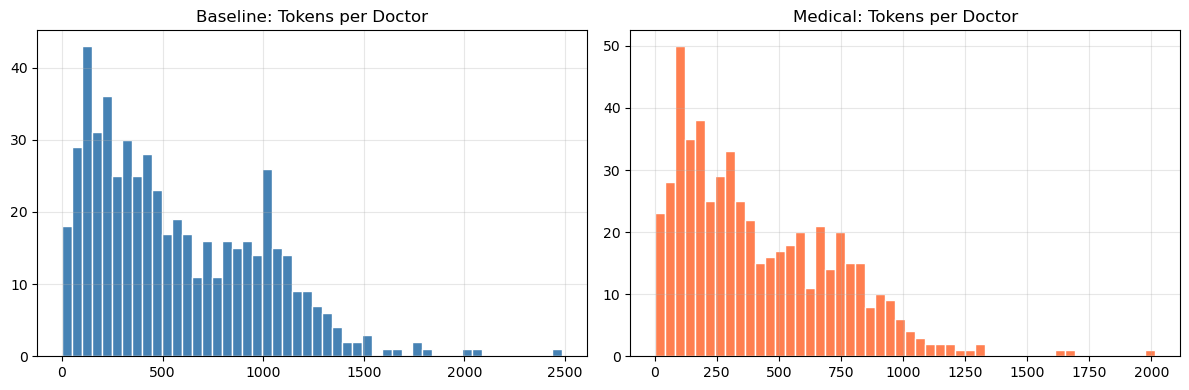

In [18]:
b_tok, m_tok = dd_baseline["n_tokens"].sum(), dd_medical["n_tokens"].sum()
print(f"Total tokens — Baseline: {b_tok:,} | Medical: {m_tok:,} | Reduction: {(1-m_tok/b_tok)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dd_baseline["n_tokens"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Baseline: Tokens per Doctor")
dd_medical["n_tokens"].hist(bins=50, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Medical: Tokens per Doctor")
plt.tight_layout(); plt.show()

---
# Part 4: Building the TF-IDF Index
---

Now we apply everything from Part 1 to our **real** doctor corpus. We build two separate indexes with identical hyperparameters:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `tokenizer=str.split` | — | Text is pre-tokenized; no further splitting needed |
| `min_df=2` | ≥ 2 doctors | Terms in only 1 doctor are likely typos or patient names |
| `max_df=0.95` | ≤ 95% | Terms in >95% of doctors are too ubiquitous to discriminate |
| `ngram_range=(1,2)` | uni + bigram | Captures multi-word medical terms ("سنگ کلیه", "دیسک کمر") |
| `max_features=60000` | 60K | Balances vocabulary coverage against memory |
| `sublinear_tf=True` | `1+log(tf)` | Prevents high-volume doctors from dominating |
| `norm="l2"` | unit vectors | Enables fair cosine similarity comparison |

In [19]:
def build_tfidf_index(doctor_docs, variant_name):
    """Build a TF-IDF index from doctor-level documents."""
    vec = TfidfVectorizer(
        tokenizer=str.split, preprocessor=None, token_pattern=None, lowercase=True,
        min_df=2, max_df=0.95, ngram_range=(1, 2), max_features=60000,
        sublinear_tf=True, norm="l2",
    )
    docs = doctor_docs["document"].tolist()
    ids = doctor_docs["doctor_id"].tolist()
    X = vec.fit_transform(docs)
    idx = {"variant": variant_name, "vectorizer": vec, "X": X, "doctor_ids": ids,
           "name_map": name_map, "specialty_map": specialty_map}
    print(f"  [{variant_name}] {X.shape[0]} doctors × {X.shape[1]:,} features | "
          f"sparsity: {1-X.nnz/(X.shape[0]*X.shape[1]):.4%} | nnz: {X.nnz:,}")
    return idx

idx_baseline = build_tfidf_index(dd_baseline, "baseline")
idx_medical = build_tfidf_index(dd_medical, "medical")

  [baseline] 545 doctors × 35,282 features | sparsity: 98.4598% | nnz: 296,160
  [medical] 543 doctors × 28,951 features | sparsity: 98.6276% | nnz: 215,751


In [20]:
# Verify: top keywords should reflect each doctor's specialty
def top_kw(idx, doc_i, n=10):
    row = idx["X"][doc_i].toarray().ravel()
    feat = idx["vectorizer"].get_feature_names_out()
    top = row.argsort()[-n:][::-1]
    return [(feat[j], round(row[j], 3)) for j in top if row[j] > 0]

for i in range(min(3, len(idx_medical["doctor_ids"]))):
    did = idx_medical["doctor_ids"][i]
    print(f"{name_map.get(did,'?')} [{specialty_map.get(did,'?')}]")
    print(f"  Baseline keywords: {', '.join(w for w,_ in top_kw(idx_baseline, i, 8))}")
    print(f"  Medical keywords:  {', '.join(w for w,_ in top_kw(idx_medical, i, 8))}\n")

دکتر علیرضا تقی زاده [متخصص پوست ، مو و زیبایی]
  Baseline keywords: پوسته, جوش, پوسته پوسته, رفع تشخیص, جوش صورت, خارش بدن, پوست, ریزش
  Medical keywords:  پوسته, جوش, پوسته پوسته, جوش صورت, خارش بدن, پوست, ریزش, رفع تشخیص

دکتر کورش فاتح [متخصص ارتوپدی - تعویض مفصل]
  Baseline keywords: فاتح, زانو, وارتروز, پارگی مینیسک, ارتروسکوپی شانه, شانه, مینیسک زانو, ارتروسکوپی
  Medical keywords:  فاتح, زانو, وارتروز, پارگی مینیسک, ارتروسکوپی شانه, شانه, مینیسک زانو, ارتروسکوپی

دکتر منصور اصفهانی [متخصص پوست ، مو و لیزر]
  Baseline keywords: آکنه جوش, اصفهانی, دکتر اصفهانی, ریزش, سکه‌ای درمان, ریزش سکه‌ای, ریزش مو, سکه‌ای
  Medical keywords:  اصفهانی, آکنه جوش, ریزش, ریزش سکه‌ای, سکه‌ای درمان, ریزش مو, سکه‌ای, پوستی



In [21]:
for idx, fname in [(idx_baseline, "tfidf_retriever_baseline.joblib"), (idx_medical, "tfidf_retriever_medical.joblib")]:
    joblib.dump(idx, fname, compress=3)
    print(f"Saved '{fname}' ({os.path.getsize(fname)/1024/1024:.1f} MB)")

Saved 'tfidf_retriever_baseline.joblib' (2.3 MB)
Saved 'tfidf_retriever_medical.joblib' (1.7 MB)


### 🔬 Real Doctor TF-IDF Explorer

In Part 1 we explored TF-IDF on 4 toy sentences. Now let's explore **real doctor data**.

The CLI below lets you:
- **Pick doctors by number** → see their top TF-IDF terms with bar charts
- **Compare two doctors** → side-by-side heatmap of shared terms
- **Search any term** → which doctors have the highest weight for it?
- **Switch variant** → see how Baseline vs Medical changes the picture

In [49]:
# ============================================================
#  Doctor TF-IDF Explorer — Pure CLI
#  Zero external dependencies beyond your project's own libs
# ============================================================

import os
import sys
import random
import unicodedata

# ─────────────────────────────────────────────────────────────
#  ① ANSI Color Palette
# ─────────────────────────────────────────────────────────────
class C:
    RESET  = '\033[0m'
    BOLD   = '\033[1m'
    DIM    = '\033[2m'
    WHITE  = '\033[97m'
    CYAN   = '\033[96m'
    YELLOW = '\033[93m'
    RED    = '\033[91m'
    GRAY   = '\033[90m'
    BLUE   = '\033[38;5;39m'
    LBLUE  = '\033[38;5;51m'
    DBLUE  = '\033[38;5;27m'
    ORANGE = '\033[38;5;208m'
    GREEN  = '\033[38;5;83m'

def cl(text, *codes) -> str:
    return ''.join(codes) + str(text) + C.RESET


# ─────────────────────────────────────────────────────────────
#  ② Persian/Arabic helpers — فقط built-in unicodedata
# ─────────────────────────────────────────────────────────────
def _is_rtl(ch: str) -> bool:
    """آیا این کاراکتر RTL (فارسی/عربی/عبری) است؟"""
    try:
        return unicodedata.bidirectional(ch) in ('R', 'AL', 'AN', 'RLE', 'RLO')
    except Exception:
        return False

def has_persian(text: str) -> bool:
    return any(_is_rtl(c) for c in text if not c.isspace())

def char_width(ch: str) -> int:
    """
    عرض نمایشی یک کاراکتر.
    کاراکترهای CJK → 2 | بقیه → 1
    """
    eaw = unicodedata.east_asian_width(ch)
    return 2 if eaw in ('W', 'F') else 1

def str_width(text: str) -> int:
    """عرض واقعی یک رشته روی ترمینال (بدون ANSI codes)."""
    # strip ANSI escape sequences first
    import re
    clean = re.sub(r'\033\[[0-9;]*m', '', text)
    return sum(char_width(c) for c in clean)

def pad(text: str, width: int, align: str = 'left') -> str:
    """
    رشته را با در نظر گرفتن عرض واقعی کاراکترهای فارسی pad می‌کند.
    align: 'left' | 'right' | 'center'
    """
    current = str_width(text)
    spaces  = max(0, width - current)
    if align == 'right':
        return ' ' * spaces + text
    if align == 'center':
        l = spaces // 2
        return ' ' * l + text + ' ' * (spaces - l)
    return text + ' ' * spaces  # left (default)

def fa(text: str) -> str:
    """
    متن فارسی را برای ترمینال آماده می‌کند.
    ترمینال‌های مدرن (Windows Terminal / GNOME / iTerm2 / VS Code)
    Reshaping و BiDi را خودشان انجام می‌دهند.
    این تابع فقط اطمینان می‌دهد string سالم unicode است.
    """
    if not text or not isinstance(text, str):
        return str(text) if text is not None else ''
    # NFC normalization — استانداردسازی فرم یونیکد
    return unicodedata.normalize('NFC', text)


# ─────────────────────────────────────────────────────────────
#  ③ Terminal / Layout Helpers
# ─────────────────────────────────────────────────────────────
def tw() -> int:
    try:
        return os.get_terminal_size().columns
    except Exception:
        return 80

def sep(char: str = '─', width: int = None, color: str = C.GRAY) -> str:
    w = width or min(tw(), 72)
    return f"{color}{char * w}{C.RESET}"

def box_header(title: str, subtitle: str = '') -> str:
    w   = min(tw(), 72)
    out = [
        f"\n{C.BOLD}{C.BLUE}{'═' * w}{C.RESET}",
        f"{C.BOLD}{C.WHITE}  {fa(title)}{C.RESET}",
    ]
    if subtitle:
        out.append(f"{C.GRAY}  {fa(subtitle)}{C.RESET}")
    out.append(f"{C.BLUE}{'═' * w}{C.RESET}")
    return '\n'.join(out)


# ─────────────────────────────────────────────────────────────
#  ④ Unicode Bar Builder
# ─────────────────────────────────────────────────────────────
_BLOCKS = ' ▏▎▍▌▋▊▉█'

def make_bar(value: float, max_val: float,
             width: int = 28, color: str = C.BLUE) -> str:
    """Smooth Unicode bar با sub-block characters."""
    if max_val == 0:
        return ' ' * width
    ratio   = max(0.0, min(1.0, value / max_val))
    filled  = ratio * width
    full    = int(filled)
    sub_idx = int((filled - full) * 8)
    sub     = _BLOCKS[sub_idx] if sub_idx else ''
    bar     = '█' * full + sub
    return f"{color}{bar:<{width}}{C.RESET}"

def gradient_bar(value: float, max_val: float, width: int = 28) -> str:
    r     = value / max_val if max_val else 0
    color = C.LBLUE if r > 0.75 else C.BLUE if r > 0.40 else C.DBLUE
    return make_bar(value, max_val, width, color)


# ─────────────────────────────────────────────────────────────
#  ⑤ Show Doctor Profile
# ─────────────────────────────────────────────────────────────
def show_doctor_profile(idx_obj, doc_idx, dd_df, n_terms: int = 12):
    did   = idx_obj['doctor_ids'][doc_idx]
    nm    = fa(name_map.get(did, f'Doctor {did}'))
    sp    = fa(specialty_map.get(did, '—'))
    row   = idx_obj['X'][doc_idx].toarray().ravel()
    feat  = idx_obj['vectorizer'].get_feature_names_out()
    top_i = row.argsort()[-n_terms:][::-1]
    terms = [(fa(feat[j]), round(float(row[j]), 4))
             for j in top_i if row[j] > 0]

    nc_arr = dd_df[dd_df['doctor_id'] == did]['n_comments'].values
    nc     = int(nc_arr[0]) if len(nc_arr) > 0 else '?'

    if not terms:
        print(cl('  No terms found for this doctor.', C.RED))
        return []

    max_w  = terms[0][1]
    BAR_W  = 30
    TERM_W = 22

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl('👨‍⚕️  ' + nm, C.BOLD, C.WHITE)}")
    print(f"  {cl('├─', C.GRAY)} Specialty : {cl(sp, C.CYAN)}")
    print(f"  {cl('├─', C.GRAY)} Doctor ID : {cl(str(did), C.GRAY)}")
    print(f"  {cl('└─', C.GRAY)} Comments  : {cl(str(nc), C.YELLOW)}")
    print(sep())
    print(f"  {cl('Top TF-IDF Terms', C.BOLD, C.WHITE)}  "
          f"{cl(f'({len(terms)} shown)', C.GRAY)}")
    print(sep('·', color=C.GRAY))

    # header
    h_score = pad('Score', 6)
    h_term  = pad('Term', TERM_W)
    h_bar   = pad('Bar', BAR_W)
    h_rank  = 'Rank'
    print(f"  {cl(h_score, C.GRAY)}  "
          f"{cl(h_term,  C.GRAY)}  "
          f"{cl(h_bar,   C.GRAY)}  "
          f"{cl(h_rank,  C.GRAY)}")
    print(sep('·', color=C.GRAY))

    for rank, (t, w) in enumerate(terms, 1):
        score_col = (C.LBLUE if w / max_w > 0.70 else
                     C.BLUE  if w / max_w > 0.35 else C.GRAY)
        row_dim   = C.DIM if rank % 2 == 0 else ''
        term_str  = pad(t, TERM_W)
        bar       = gradient_bar(w, max_w, BAR_W)

        print(f"  {score_col}{w:.4f}{C.RESET}  "
              f"{row_dim}{term_str}{C.RESET}  "
              f"{bar}  "
              f"{cl(f'#{rank}', C.GRAY)}")

    print(sep('═', color=C.BLUE))
    return terms


# ─────────────────────────────────────────────────────────────
#  ⑥ Compare Two Doctors (back-to-back bars)
# ─────────────────────────────────────────────────────────────
def compare_two_doctors(idx_obj, idx_a, idx_b, dd_df, n_terms: int = 10):
    ids   = idx_obj['doctor_ids']
    feat  = idx_obj['vectorizer'].get_feature_names_out()
    X     = idx_obj['X']

    row_a = X[idx_a].toarray().ravel()
    row_b = X[idx_b].toarray().ravel()

    top_a   = set(row_a.argsort()[-n_terms:][::-1])
    top_b   = set(row_b.argsort()[-n_terms:][::-1])
    all_top = sorted(top_a | top_b,
                     key=lambda j: max(row_a[j], row_b[j]),
                     reverse=True)

    nm_a = fa(name_map.get(ids[idx_a], ids[idx_a]))
    nm_b = fa(name_map.get(ids[idx_b], ids[idx_b]))
    sp_a = fa(specialty_map.get(ids[idx_a], '—'))
    sp_b = fa(specialty_map.get(ids[idx_b], '—'))

    max_val = max(
        [row_a[j] for j in all_top] + [row_b[j] for j in all_top],
        default=1.0
    )

    BAR_W  = 18
    TERM_W = 18

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl('📊 Doctor Comparison', C.BOLD, C.WHITE)}")
    print(sep())
    print(f"  {cl('A ►', C.BOLD, C.BLUE)}  "
          f"{cl(nm_a, C.BLUE)}  {cl('[' + sp_a + ']', C.GRAY)}")
    print(f"  {cl('B ►', C.BOLD, C.ORANGE)}  "
          f"{cl(nm_b, C.ORANGE)}  {cl('[' + sp_b + ']', C.GRAY)}")
    print(sep())

    hdr = (f"  {'ScoreA':>8}  "
           f"{'◀ Dr.A':>{BAR_W}}  "
           f"{'Term':^{TERM_W}}  "
           f"{'Dr.B ▶':<{BAR_W}}  "
           f"{'ScoreB':<8}")
    print(cl(hdr, C.GRAY))
    print(sep('·', color=C.GRAY))

    for j in all_top:
        wa   = float(row_a[j])
        wb   = float(row_b[j])
        term = pad(fa(feat[j]), TERM_W, 'center')

        a_fill = int((wa / max_val) * BAR_W)
        b_fill = int((wb / max_val) * BAR_W)
        a_bar  = f"{C.BLUE}{' ' * (BAR_W - a_fill)}{'█' * a_fill}{C.RESET}"
        b_bar  = f"{C.ORANGE}{'█' * b_fill}{' ' * (BAR_W - b_fill)}{C.RESET}"

        diff   = wa - wb
        marker = (cl('◀', C.BLUE)   if diff >  0.001 else
                  cl('▶', C.ORANGE) if diff < -0.001 else
                  cl('═', C.GRAY))

        print(f"  {C.BLUE}{wa:.4f}{C.RESET}  "
              f"{a_bar}  "
              f"{cl(term, C.WHITE)}  "
              f"{b_bar}  "
              f"{C.ORANGE}{wb:.4f}{C.RESET} {marker}")

    print(sep('═', color=C.BLUE))


# ─────────────────────────────────────────────────────────────
#  ⑦ Search Term
# ─────────────────────────────────────────────────────────────
def search_term_in_index(idx_obj, term: str, top_n: int = 10):
    vec = idx_obj['vectorizer']
    X   = idx_obj['X']
    ids = idx_obj['doctor_ids']

    t = term.lower().strip()

    if t not in vec.vocabulary_:
        feat    = list(vec.get_feature_names_out())
        matches = [f for f in feat if t in f][:8]
        print()
        if matches:
            print(f"  {cl('⚠️  Not exact. Did you mean:', C.YELLOW)}")
            for i, m in enumerate(matches, 1):
                print(f"    {cl(str(i) + '.', C.GRAY)}  {cl(fa(m), C.CYAN)}")
        else:
            print(f"  {cl('❌  Term not found in vocabulary.', C.RED)}")
        return

    ti       = vec.vocabulary_[t]
    idf      = float(vec.idf_[ti])
    col      = X[:, ti].toarray().ravel()
    top_docs = col.argsort()[-top_n:][::-1]

    results = []
    for di in top_docs:
        w = float(col[di])
        if w == 0:
            break
        did = ids[di]
        results.append((fa(name_map.get(did, did)),
                        fa(specialty_map.get(did, '—')),
                        w))

    if not results:
        print(f"\n  {cl('No results found.', C.GRAY)}")
        return

    max_w  = results[0][2]
    BAR_W  = 30
    NAME_W = 22

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl('🔎 Search Results', C.BOLD, C.WHITE)}")
    print(f"  {cl('Term :', C.GRAY)} {cl(fa(term), C.CYAN, C.BOLD)}")
    print(f"  {cl('IDF  :', C.GRAY)} {cl(f'{idf:.4f}', C.YELLOW)}")
    print(f"  {cl('Docs :', C.GRAY)} {cl(str(len(results)), C.GRAY)}")
    print(sep('·', color=C.GRAY))

    h_rank = pad('Rank', 4)
    h_scr  = pad('Score', 6)
    h_bar  = pad('Bar', BAR_W)
    h_nm   = pad('Doctor', NAME_W)
    print(f"  {cl(h_rank, C.GRAY)}  "
          f"{cl(h_scr,  C.GRAY)}  "
          f"{cl(h_bar,  C.GRAY)}  "
          f"{cl(h_nm,   C.GRAY)}")
    print(sep('·', color=C.GRAY))

    for i, (nm, sp, w) in enumerate(results, 1):
        r         = w / max_w
        score_col = C.LBLUE if r > 0.75 else C.BLUE if r > 0.4 else C.GRAY
        bar       = make_bar(w, max_w, BAR_W, score_col)
        nm_str    = pad(nm, NAME_W)

        print(f"  {cl(f'#{i:>2}', C.GRAY)}  "
              f"{score_col}{w:.4f}{C.RESET}  "
              f"{bar}  "
              f"{cl(nm_str, C.WHITE)}  "
              f"{cl('(' + sp[:14] + ')', C.GRAY)}")

    print(sep('═', color=C.BLUE))


# ─────────────────────────────────────────────────────────────
#  ⑧ Top-N Doctors by TF-IDF Mass
# ─────────────────────────────────────────────────────────────
def show_top_n(idx_obj, count: int = 10):
    ids    = idx_obj['doctor_ids']
    X      = idx_obj['X']
    count  = min(count, len(ids))
    masses = X.sum(axis=1).A1
    top_i  = masses.argsort()[-count:][::-1]
    max_m  = float(masses[top_i[0]])
    BAR_W  = 28

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl(f'🏆 Top {count} Doctors by TF-IDF Mass', C.BOLD, C.WHITE)}")
    print(sep('·', color=C.GRAY))

    for rank, di in enumerate(top_i, 1):
        did  = ids[di]
        nm   = fa(name_map.get(did, did))
        sp   = fa(specialty_map.get(did, '—'))
        mass = float(masses[di])
        bar  = gradient_bar(mass, max_m, BAR_W)

        print(f"  {cl(f'#{rank:>3}', C.GRAY)}  "
              f"{bar}  "
              f"{cl(f'{mass:8.2f}', C.YELLOW)}  "
              f"{cl(pad(nm, 22), C.WHITE)}  "
              f"{cl('(' + sp[:14] + ')', C.GRAY)}")

    print(sep('═', color=C.BLUE))


# ─────────────────────────────────────────────────────────────
#  ⑨ List Doctors
# ─────────────────────────────────────────────────────────────
def list_doctors(idx_obj, start: int = 0, page: int = 20):
    ids   = idx_obj['doctor_ids']
    n     = len(ids)
    start = max(0, min(start, n - 1))
    end   = min(start + page, n)

    print()
    print(sep('─', color=C.GRAY))
    print(f"  {cl(f'Doctors [{start} – {end-1}] of {n}', C.BOLD, C.WHITE)}")
    print(sep('·', color=C.GRAY))

    for i in range(start, end):
        did = ids[i]
        nm  = fa(name_map.get(did, did))
        sp  = fa(specialty_map.get(did, '—'))
        print(f"    {cl(f'[{i:>4}]', C.GRAY)}  "
              f"{cl(pad(nm, 28), C.WHITE)}  "
              f"{cl('(' + sp[:20] + ')', C.GRAY)}")

    print(sep('─', color=C.GRAY))
    if end < n:
        print(f"  {cl(f'→ type: list {end}  for next page', C.DIM)}")


# ─────────────────────────────────────────────────────────────
#  ⑩ Help
# ─────────────────────────────────────────────────────────────
HELP_ROWS = [
    ('<number>',         'نمایش پروفایل پزشک با این شماره'),
    ('compare <a> <b>',  'مقایسه دو پزشک'),
    ('search  <term>',   'جستجوی یک واژه در همه پزشک‌ها'),
    ('top     [n]',      'بهترین n پزشک بر اساس TF-IDF (پیش‌فرض ۱۰)'),
    ('list    [start]',  'فهرست ۲۰ پزشک از شماره start'),
    ('random',           'نمایش یک پزشک تصادفی'),
    ('help',             'نمایش این راهنما'),
    ('exit / q',         'خروج'),
]

def print_help():
    print(f"\n  {cl('دستورات:', C.BOLD, C.WHITE)}")
    for cmd_str, desc in HELP_ROWS:
        cmd_col  = cl(pad(cmd_str, 18), C.CYAN)
        desc_col = cl(fa(desc), C.GRAY)
        print(f"    {cmd_col}  {desc_col}")


# ─────────────────────────────────────────────────────────────
#  ⑪ Main CLI Loop
# ─────────────────────────────────────────────────────────────
def doctor_explorer_cli(idx_obj, dd_df, variant_label: str):
    ids = idx_obj['doctor_ids']
    n   = len(ids)

    print(box_header(
        f"🔬 Doctor TF-IDF Explorer  [{variant_label.upper()}]",
        f"{n} doctors  |  {idx_obj['X'].shape[1]:,} vocabulary features"
    ))

    print_help()
    list_doctors(idx_obj, start=0, page=10)

    while True:
        try:
            raw = input(
                f"\n🔍 {cl('[' + variant_label + ']', C.CYAN)}"
                f"{cl('> ', C.GRAY)}"
            ).strip()
        except (EOFError, KeyboardInterrupt):
            print(f"\n{cl('  خداحافظ!', C.GRAY)}\n")
            break

        if not raw:
            continue

        low   = raw.lower()
        parts = raw.split()

        # ── exit ─────────────────────────────────────────────
        if low in {'exit', 'quit', 'q', 'خروج'}:
            print(f"\n{cl('  خداحافظ!', C.GRAY)}\n")
            break

        # ── help ─────────────────────────────────────────────
        elif low in {'help', 'راهنما'}:
            print_help()

        # ── random ───────────────────────────────────────────
        elif low in {'random', 'تصادفی'}:
            show_doctor_profile(idx_obj, random.randint(0, n - 1), dd_df)

        # ── top [n] ──────────────────────────────────────────
        elif low.startswith('top'):
            count = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 10
            show_top_n(idx_obj, count)

        # ── list [start] ─────────────────────────────────────
        elif low.startswith('list'):
            start = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
            list_doctors(idx_obj, start=start, page=20)

        # ── compare <a> <b> ──────────────────────────────────
        elif low.startswith('compare'):
            if len(parts) >= 3:
                try:
                    a, b = int(parts[1]), int(parts[2])
                    if 0 <= a < n and 0 <= b < n:
                        compare_two_doctors(idx_obj, a, b, dd_df)
                    else:
                        print(cl(f'  عدد باید بین ۰ تا {n-1} باشد.', C.RED))
                except ValueError:
                    print(cl('  استفاده: compare <الف> <ب>', C.YELLOW))
            else:
                print(cl('  استفاده: compare <الف> <ب>', C.YELLOW))

        # ── search <term> ─────────────────────────────────────
        elif low.startswith('search '):
            term = raw[7:].strip()
            if term:
                search_term_in_index(idx_obj, term)
            else:
                print(cl('  استفاده: search <واژه>', C.YELLOW))

        # ── <number> → profile ───────────────────────────────
        else:
            try:
                di = int(raw)
                if 0 <= di < n:
                    show_doctor_profile(idx_obj, di, dd_df)
                else:
                    print(cl(f'  عدد باید بین ۰ تا {n-1} باشد.', C.RED))
            except ValueError:
                # implicit term search
                search_term_in_index(idx_obj, raw)


# ── اجرا ─────────────────────────────────────────────────────
doctor_explorer_cli(idx_medical, dd_medical, 'medical')


════════════════════════════════════════════════════════════════════════
  🔬 Doctor TF-IDF Explorer  [MEDICAL]
  543 doctors  |  28,951 vocabulary features
════════════════════════════════════════════════════════════════════════

  دستورات:
    <number>            نمایش پروفایل پزشک با این شماره
    compare <a> <b>     مقایسه دو پزشک
    search  <term>      جستجوی یک واژه در همه پزشک‌ها
    top     [n]         بهترین n پزشک بر اساس TF-IDF (پیش‌فرض ۱۰)
    list    [start]     فهرست ۲۰ پزشک از شماره start
    random              نمایش یک پزشک تصادفی
    help                نمایش این راهنما
    exit / q            خروج

────────────────────────────────────────────────────────────────────────
  Doctors [0 – 9] of 543
········································································
    [   0]  دکتر علیرضا تقی زاده          (متخصص پوست ، مو و زی)
    [   1]  دکتر کورش فاتح                (متخصص ارتوپدی - تعوی)
    [   2]  دکتر منصور اصفهانی            (متخصص پوست ، مو و لی)
    [   


🔍 [medical]>  5



════════════════════════════════════════════════════════════════════════
  👨‍⚕️  دکتر بهروز براتی
  ├─ Specialty : فلوشیپ جراحی گوش
  ├─ Doctor ID : 103641
  └─ Comments  : 203
────────────────────────────────────────────────────────────────────────
  Top TF-IDF Terms  (12 shown)
········································································
  Score   Term                    Bar                             Rank
········································································
  0.1103  براتی                   ██████████████████████████████  #1
  0.1038  عمل گوش                 ████████████████████████████▏   #2
  0.0970  دکتربراتی               ██████████████████████████▍     #3
  0.0925  کلستاتوم                █████████████████████████▏      #4
  0.0890  اسپری                   ████████████████████████▏       #5
  0.0804  گوش میانی               █████████████████████▊          #6
  0.0783  برند                    █████████████████████▎          #7
  0.0779  میانی   

In [23]:
# --- Run Baseline Explorer ---
doctor_explorer_cli(idx_baseline, dd_baseline, 'baseline')


  🔬 Doctor TF-IDF Explorer [BASELINE]
  545 doctors | 35,282 features
  Commands:
    <number>          → show doctor profile (0 to 544)
    compare <a> <b>   → compare two doctors
    search <term>     → find term across all doctors
    random            → show a random doctor
    exit              → quit

  First 10 doctors:
    [   0] دکتر علیرضا تقی زاده  (متخصص پوست ، مو و زی)
    [   1] دکتر کورش فاتح  (متخصص ارتوپدی - تعوی)
    [   2] دکتر منصور اصفهانی  (متخصص پوست ، مو و لی)
    [   3] دکتر زهره لواسانی  (متخصص زنان و زایمان )
    [   4] دکتر مسعود یاوری  (فلوشیپ جراحی دست)
    [   5] دکتر بهروز براتی  (فلوشیپ جراحی گوش)
    [   6] دکتر علیرضا سینا  (متخصص جراحی کلیه و م)
    [   7] دکتر یوسف یعقوبلو  (جراح گوش و حلق بینی )
    [   8] دکتر محمد مهدی تقدیری  (فوق تخصص مغز و اعصاب)
    [   9] پروفسور نعمت اله عطائی  (فوق تخصص کلیه و مجار)
    ...  (545 total)



🔍 [baseline]>  quit


Done.


---
# Part 5: Query Preprocessing
---

## The Golden Rule of IR

The query **must** undergo the **exact same preprocessing** as the corpus documents. If the corpus was lowercased, the query must be lowercased. If the corpus had ZWNJ characters removed, the query must too.

Any mismatch → terms won't match → retrieval fails silently.

Our preprocessing pipeline (from the Preprocessing notebook):

```
Raw query
  → Remove control chars (ZWNJ, direction marks, BOM)
  → Convert digits (۰→0, ١→1)
  → Normalize Arabic→Persian (ي→ی, ك→ک, أ→ا, ة→ه)
  → Remove non-standard chars (emoji, symbols)
  → Fix elongation (عاااااالی → عاالی)
  → hazm Normalizer (spacing, diacritics)
  → Domain deglue (درحال → در حال)
  → hazm Tokenizer + remove standard stopwords (protect negations!)
  → [Medical variant only] remove medical stopwords
  = Ready for vectorizer
```

### Protecting Negation Words

Standard Persian stopword lists include negation words like "نه", "نیست", "نمی". If we remove these, the sentence "از دکتر راضی **نیستم**" (I am **not** satisfied) becomes "از دکتر راضی" (I am satisfied) — completely inverting the meaning. We explicitly protect: `{نه, نخیر, نیست, نمی, نبود, نشد, بدون}`.

In [24]:
from hazm import Normalizer, WordTokenizer, stopwords_list

DIGIT_MAP = str.maketrans("۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩", "01234567890123456789")
CTRL_RE = re.compile(r"[\u200c\u200d\u200e\u200f\u202a-\u202e\ufeff\u00ad\u2060\u180e]")
KEEP_RE = re.compile(r"[^0-9A-Za-z\u0600-\u06FF\s]")
ELONG_RE = re.compile(r"(\S)\1{2,}")
PUNCT_RE = re.compile(r"[،؛؟!٪«»]+")
DOT_RE = re.compile(r"(?<!\d)\.(?!\d)")
MULTI_SP = re.compile(r"\s+")

DEGLUE = [
    (re.compile(r"(?<!\S)درحال(?!\S)"), "در حال"),
    (re.compile(r"(?<!\S)باسلام(?!\S)"), "با سلام"),
    (re.compile(r"(?<!\S)خداروشکر(?!\S)"), "خدا رو شکر"),
    (re.compile(r"(?<!\S)فوقالعاده(?!\S)"), "فوق العاده"),
]

_hz_norm = Normalizer(correct_spacing=True, remove_diacritics=True, remove_specials_chars=False,
                      decrease_repeated_chars=False, persian_style=True, persian_numbers=False)
_hz_tok = WordTokenizer(separate_emoji=False, replace_links=False, replace_ids=False)
_NEGATION_KEEP = {"نه", "نخیر", "نیست", "نمی", "نمي", "نبود", "نشد", "بدون"}
_std_sw = set(stopwords_list()) - _NEGATION_KEEP

def preprocess_query(raw):
    """Full preprocessing pipeline → baseline text (space-tokenized)."""
    t = CTRL_RE.sub(" ", str(raw))
    t = t.translate(DIGIT_MAP)
    for old, new in [("ي","ی"),("ك","ک"),("أ","ا"),("إ","ا"),("ؤ","و"),("ة","ه"),("ٱ","ا")]:
        t = t.replace(old, new)
    t = KEEP_RE.sub(" ", t)
    t = ELONG_RE.sub(r"\1\1", t)
    t = PUNCT_RE.sub(" ", t)
    t = DOT_RE.sub(" ", t)
    t = MULTI_SP.sub(" ", t).strip()
    t = _hz_norm.normalize(t)
    for pat, repl in DEGLUE:
        t = pat.sub(repl, t)
    t = MULTI_SP.sub(" ", t).strip()
    toks = [x for x in _hz_tok.tokenize(t) if len(x) >= 2]
    toks_ns = [x for x in toks if x not in _std_sw or x in _NEGATION_KEEP]
    return " ".join(toks_ns) if toks_ns else " ".join(toks)

def preprocess_query_medical(raw):
    """Baseline + medical stopword filter."""
    baseline = preprocess_query(raw)
    medical, _ = filter_medical_stopwords(baseline, effective_medical_sw, MEDICAL_ALLOWLIST_LATIN, MEDICAL_STOPWORD_BIGRAMS)
    return baseline, medical

In [25]:
test_queries = ["سنگ کلیه", "دیسک کمر", "HPV", "دکتر خوب با حوصله", "MRI گردن"]
print(f"{'Raw Query':<25} {'Baseline':<25} {'Medical'}")
print("-" * 75)
for q in test_queries:
    b, m = preprocess_query_medical(q)
    print(f"{q:<25} {b:<25} {m}")

Raw Query                 Baseline                  Medical
---------------------------------------------------------------------------
سنگ کلیه                  سنگ کلیه                  سنگ کلیه
دیسک کمر                  دیسک کمر                  دیسک کمر
HPV                       HPV                       HPV
دکتر خوب با حوصله         دکتر حوصله                
MRI گردن                  MRI گردن                  MRI گردن


---
# Part 6: Retrieval — Cosine Similarity Search
---

The retrieval step is conceptually simple:

1. **Vectorize** the query using the fitted vectorizer (same vocabulary and IDF weights)
2. **Compute cosine similarity** between the query vector and all doctor vectors
3. **Sort** by similarity and return the top-K

Because both query and document vectors are L2-normalized, cosine similarity is just a matrix-vector dot product — extremely fast even for thousands of doctors.

In [26]:
def retrieve(idx, query_text, top_k=10):
    """Retrieve top-K doctors by cosine similarity."""
    if not query_text.strip(): return []
    qv = idx["vectorizer"].transform([query_text])
    if qv.nnz == 0: return []  # all query terms are OOV
    sims = cosine_similarity(qv, idx["X"]).ravel()
    top_i = np.argsort(-sims)[:top_k]
    return [(idx["doctor_ids"][i], float(sims[i])) for i in top_i]

def display_results(results, idx, query):
    """Pretty-print retrieval results with doctor metadata."""
    print(f"\nQuery: '{query}' — Top {len(results)} results:\n")
    for rank, (did, sim) in enumerate(results, 1):
        nm = name_map.get(did, "")
        sp = specialty_map.get(did, "")
        kw = ", ".join(w for w, _ in top_kw(idx, idx["doctor_ids"].index(did), 6))
        print(f"  {rank:>2}. sim={sim:.4f}  {nm}  [{sp}]")
        print(f"      keywords: {kw}")

In [27]:
# Clinical queries → Medical index
for q_raw in ["سنگ کلیه", "دیسک کمر", "ریزش مو"]:
    _, q_med = preprocess_query_medical(q_raw)
    display_results(retrieve(idx_medical, q_med, 5), idx_medical, q_raw)


Query: 'سنگ کلیه' — Top 5 results:

   1. sim=0.4386  دکتر محمد کمالی  [متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست )]
      keywords: کلیه, سنگ کلیه, سنگ, ماهر بود, کلیه دفع, حالب انجام
   2. sim=0.3085  دکتر ابراهیم رسولیان هروی  [متخصص جراحی کلیه و مجاری ادراری - ارولوژی]
      keywords: کلیه, پروستات, سنگ, کلیه سنگ, سنگ کلیه, سیستسکوپی
   3. sim=0.2932  دکتر رضا سرهنگ نژاد  [متخصص جراحی کلیه و مجاری ادراری و تناسلی]
      keywords: کلیه کارشون, خوش‌اخلاق سنگ, کلیه, سنگ کلیه, سنگ, کلیه سنگ
   4. sim=0.2855  دکتر عرفان جلوه مقدم  [متخصص جراحی کلیه و مجاری ادراری ( اورولوژی)]
      keywords: کلیه, سنگ, سنگ کلیه, پروستات, مشکل پروستات, کلیه ومجاری
   5. sim=0.2818  دکتر الهام تهرانی پور  [فلوشیپ اندویورولوژی]
      keywords: نفت, سنگ‌شکن, کلیه, سنگ کلیه, سنگ, کیله

Query: 'دیسک کمر' — Top 5 results:

   1. sim=0.3028  دکتر حامد جوادیان  [متخصص جراحی مغز و اعصاب دیسک و ستون فقرات]
      keywords: کمر حرفه‌ای, هست حرفه‌ای, حرف میزنه, گذاشتن مریض, مریض هست, الان ده
   2. sim=0.2499  دک

In [28]:
# Service queries → Baseline index (these words are removed in Medical)
for q_raw in ["با حوصله", "بد برخورد"]:
    q_b = preprocess_query(q_raw)
    display_results(retrieve(idx_baseline, q_b, 5), idx_baseline, q_raw)


Query: 'با حوصله' — Top 5 results:

   1. sim=0.3263  دکتر زهرا بیگم موسوی  [متخصص بیماری های پوست]
      keywords: صبور حوصله, صبور, حوصله
   2. sim=0.1104  دکتر ماجد غفاری  [جراح کلیه و مجاری ادراری تناسلی - ارولوژیست]
      keywords: زمان میزارن, هستن زمان, میزارن بیمار, دقیق هستن, حوصله دقیق, میزارن
   3. sim=0.0739  دکتر زهرا کرباسی  [فلوشیپ جراحی سر و گردن]
      keywords: واقعا حرفه, صورتشون, حرفه خودشون, طلا هستن, می‌خواستم, غده
   4. sim=0.0714  دکتر فاطمه دیانتی تیلکی  [متخصص زنان و زایمان]
      keywords: هستم درود, خورد حوصله, وعالی فعلا, خوش‌اخلاق وعالی, ایرادشون, درمورد بیماری
   5. sim=0.0680  دکتر مولود رایانی  [متخصص مغز و اعصاب و نخاع]
      keywords: ایشون بد, ممنونم راضی, بود مغز, نمی‌شد نسخه, کمک بهم, سلام سردردهای

Query: 'بد برخورد' — Top 5 results:

   1. sim=0.0558  دکتر سمیه سالکی  [فلوشیپ نازایی]
      keywords: رایگان, توانمد, توانمند مهربان, ارتباط برقرار, سونوی, بیمار ارتباط
   2. sim=0.0510  دکتر حمیدرضا رخصت یزدی  [متخصص مغز و اعصاب و ستون فقرات]
      

---
# Part 7: Recommendation-Aware Reranking
---

## The Problem: Similarity ≠ Quality

Cosine similarity measures **textual relevance** — how much a doctor's review text matches the query. But a doctor could have many reviews mentioning "سنگ کلیه" because patients are *complaining* about misdiagnosis or failed treatment.

We need to combine:
- **Textual relevance** (cosine sim) — does this doctor's text match the query?
- **Patient satisfaction** — among the matching reviews, how many patients actually recommend this doctor?

## The Reranking Formula

$$\text{final\_score} = \underbrace{\text{sim}}_{\text{text match}} \times \underbrace{\text{smooth\_recommend}}_{\text{quality signal}} \times \underbrace{\log(1 + \text{q\_support})}_{\text{evidence strength}}$$

Where:
- **q_support** = number of this doctor's comments that contain at least one query term
- **q_recommend** = of those, how many have rate ≥ 4 (i.e., patient recommends)
- **smooth_recommend** = $(\text{q\_recommend} + 1) / (\text{q\_support} + 2)$ — Bayesian smoothing with Beta(1,1) prior

### Why Bayesian Smoothing?

Without smoothing, a doctor with 1 matching review (1/1 = 100% recommend) would outrank a doctor with 45 positive out of 50 matching reviews (90%). But we **trust** the 45/50 far more.

The Beta(1,1) prior acts as adding 1 pseudo-positive and 1 pseudo-negative:

| Doctor | q_rec/q_sup | Raw Rate | Smoothed Rate |
|--------|-------------|----------|---------------|
| A | 1/1 | 100% | (1+1)/(1+2) = **66.7%** |
| B | 45/50 | 90% | (45+1)/(50+2) = **88.5%** |

Doctor B correctly ranks higher. ✅

### Why log(1 + support)?

A doctor with 50 query-matching reviews provides much stronger evidence than one with 2. But the growth should be **sublinear** — 100 reviews shouldn't be 50× better than 2. Logarithmic scaling provides a reasonable compromise.

In [29]:
def build_evidence(df, text_col):
    """Build per-doctor evidence store: comment texts + recommendation flags."""
    valid = df[df[text_col].str.strip() != ""].copy()
    valid["rate_num"] = pd.to_numeric(valid["rate"], errors="coerce")
    valid["is_rec"] = valid["rate_num"].ge(4.0).fillna(False)
    evidence = {}
    for did, g in valid.groupby("doctor_id"):
        evidence[did] = {"texts": g[text_col].tolist(), "is_rec": g["is_rec"].tolist()}
    return evidence

evidence_baseline = build_evidence(comments_df, "text_baseline")
evidence_medical = build_evidence(comments_df, "text_medical")
print(f"Evidence loaded: {len(evidence_medical):,} doctors")

Evidence loaded: 543 doctors


In [30]:
def comment_matches(comment_text, terms):
    """Check if comment contains at least one query term (token-boundary safe)."""
    padded = f" {comment_text} "
    return any(f" {t} " in padded for t in terms)

def get_query_terms(vectorizer, query_text):
    """Extract terms as the vectorizer sees them (including bigrams)."""
    if not query_text.strip(): return []
    analyzer = vectorizer.build_analyzer()
    seen = set()
    return [t for t in analyzer(query_text) if t not in seen and not seen.add(t)]

In [31]:
def rerank(idx, evidence, candidates, query_text):
    """Rerank candidates: final = sim × smooth_recommend × log1p(support)."""
    terms = get_query_terms(idx["vectorizer"], query_text)
    results = []
    for did, sim in candidates:
        ev = evidence.get(did)
        if not ev:
            results.append({"did": did, "sim": sim, "final": 0.0, "support": 0, "rec": 0, "rec_pct": 0})
            continue
        matched, matched_rec = 0, 0
        for txt, rec in zip(ev["texts"], ev["is_rec"]):
            if comment_matches(txt, terms):
                matched += 1
                if rec: matched_rec += 1
        smooth = (matched_rec + 1) / (matched + 2)   # Beta(1,1) smoothing
        final = sim * smooth * np.log1p(matched)
        results.append({"did": did, "sim": sim, "final": final,
                       "support": matched, "rec": matched_rec,
                       "rec_pct": (matched_rec/matched*100) if matched else 0})
    results.sort(key=lambda r: (-r["final"], -r["sim"]))
    return results

In [32]:
# --- Rerank demo: before vs after ---
q_raw = "سنگ کلیه"
_, q_med = preprocess_query_medical(q_raw)
candidates = retrieve(idx_medical, q_med, top_k=10)
reranked = rerank(idx_medical, evidence_medical, candidates, q_med)

print(f"Query: '{q_raw}'\n")
print(f"{'#':>3} {'Doctor':>10} {'Sim':>7} {'Final':>7} {'Sup':>5} {'Rec%':>6}  {'Name':<20} {'Specialty'}")
print("-" * 85)
for i, r in enumerate(reranked[:10], 1):
    print(f"{i:>3} {r['did']:>10} {r['sim']:>7.4f} {r['final']:>7.4f} {r['support']:>5} {r['rec_pct']:>5.1f}%"
          f"  {name_map.get(r['did'],''):<20} {specialty_map.get(r['did'],'')}")

Query: 'سنگ کلیه'

  #     Doctor     Sim   Final   Sup   Rec%  Name                 Specialty
-------------------------------------------------------------------------------------
  1     249879  0.2932  0.7530    19  89.5%  دکتر رضا سرهنگ نژاد  متخصص جراحی کلیه و مجاری ادراری و تناسلی
  2     311174  0.2793  0.6652    12 100.0%  دکتر امیررضا عابدی   جراح کلیه و مجاری ادراری تناسلی
  3     278895  0.2696  0.6642    13 100.0%  دکتر فرشاد قلی پور   متخصص جراحی کلیه و مجاری ادراری
  4     241599  0.2855  0.6529    13  92.3%  دکتر عرفان جلوه مقدم متخصص جراحی کلیه و مجاری ادراری ( اورولوژی)
  5     301319  0.4386  0.5882     4 100.0%  دکتر محمد کمالی      متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست )
  6     301955  0.2781  0.5140     7 100.0%  دکتر علیرضا رضایی    جراح و متخصص اورولوژی - کلیه و مجاری ادراری
  7     182007  0.2767  0.4249     5 100.0%  دکتر منوچهر امیری    متخصص جراحی کلیه و مجاری ادراری ( اورولوژی )
  8     293669  0.2818  0.3780     4 100.0%  دکتر الهام تهرانی پور فلوش

---
# Part 8: Holdout Evaluation
---

## Evaluation Strategy

How do we measure retriever quality? We use a **holdout** approach:

1. For each doctor with ≥ 5 comments, split: **80% train**, **20% test**
2. Build the TF-IDF index using only train comments
3. Use each test comment as a query → retrieve → check if the **correct doctor** appears in top-K

**Intuition:** If a patient's comment about "سنگ کلیه" belongs to Dr. X, then using that comment as a query should retrieve Dr. X among the top results.

### Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Recall@K** | % of queries where correct doctor is in top K | Higher = better; @5 is most practical |
| **MRR** | Mean of 1/rank across queries | Higher = better; 1.0 means always rank 1 |
| **Mean Rank** | Average rank of the correct doctor | Lower = better |

In [33]:
def holdout_eval(df, text_col, variant_name, min_comments=5, holdout_frac=0.2, seed=42):
    """Run holdout evaluation. Returns metrics dict."""
    rng = np.random.default_rng(seed)
    valid = df[df[text_col].str.strip() != ""].copy()
    
    train_parts, test_parts = [], []
    for did, g in valid.groupby("doctor_id"):
        if len(g) < min_comments: continue
        g = g.reset_index(drop=True)
        n_test = max(1, min(int(len(g) * holdout_frac), len(g) - 1))
        idx = np.arange(len(g)); rng.shuffle(idx)
        test_parts.append(g.iloc[idx[:n_test]])
        train_parts.append(g.iloc[idx[n_test:]])
    
    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)
    
    # Build index on train only
    doc_corpus = (train_df.groupby("doctor_id")[text_col]
                  .apply(lambda x: " ".join(x)).reset_index()
                  .rename(columns={text_col: "document"}))
    vec = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None,
                          lowercase=True, min_df=2, max_df=0.95, ngram_range=(1,2),
                          max_features=60000, sublinear_tf=True, norm="l2")
    X = vec.fit_transform(doc_corpus["document"].tolist())
    did_to_idx = {d: i for i, d in enumerate(doc_corpus["doctor_id"].tolist())}
    
    # Evaluate each test comment as a query
    test_df = test_df[test_df["doctor_id"].isin(did_to_idx)].copy()
    Q = vec.transform(test_df[text_col].tolist())
    sims = cosine_similarity(Q, X)
    
    ranks = []
    for i in range(len(test_df)):
        true_idx = did_to_idx[test_df.iloc[i]["doctor_id"]]
        rank = int(np.sum(sims[i] > sims[i][true_idx])) + 1
        ranks.append(rank)
    
    ranks = np.array(ranks, dtype=float)
    return {
        "variant": variant_name, "doctors": len(doc_corpus), "queries": len(ranks),
        "Recall@1": float(np.mean(ranks <= 1)),
        "Recall@5": float(np.mean(ranks <= 5)),
        "Recall@10": float(np.mean(ranks <= 10)),
        "Recall@20": float(np.mean(ranks <= 20)),
        "MRR": float(np.mean(1.0 / ranks)),
        "Mean Rank": float(np.mean(ranks)),
        "Median Rank": float(np.median(ranks)),
    }

In [34]:
print("Running holdout evaluation (this may take a minute)...\n")
m_base = holdout_eval(comments_df, "text_baseline", "baseline")
m_med = holdout_eval(comments_df, "text_medical", "medical")

eval_df = pd.DataFrame([m_base, m_med]).set_index("variant")
print(eval_df.to_string())

Running holdout evaluation (this may take a minute)...

          doctors  queries  Recall@1  Recall@5  Recall@10  Recall@20       MRR   Mean Rank  Median Rank
variant                                                                                                
baseline      535    13081  0.072472  0.134393   0.189512   0.267640  0.114919  119.954591         69.0
medical       535    11090  0.050225  0.127953   0.192876   0.283138  0.100205  105.657259         57.0


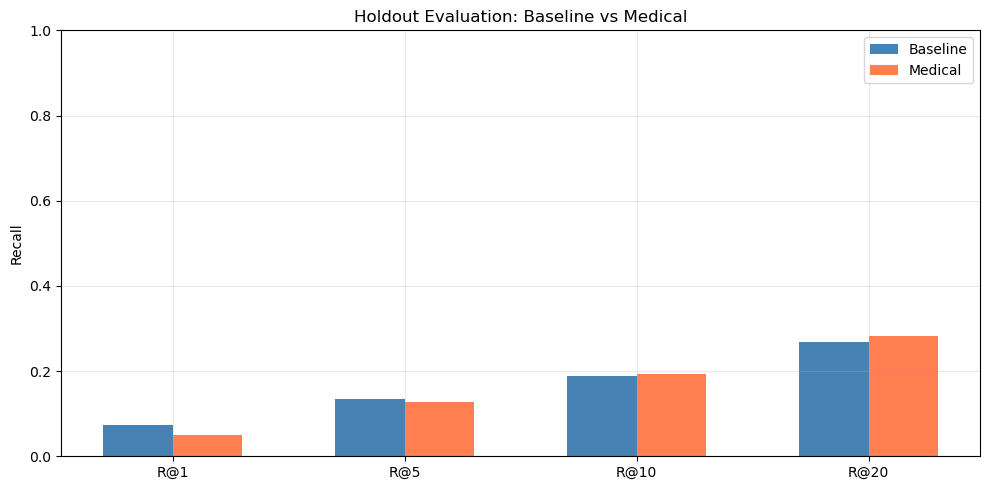

In [35]:
ks = ["Recall@1", "Recall@5", "Recall@10", "Recall@20"]
x = np.arange(len(ks))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.15, [m_base[k] for k in ks], 0.3, label="Baseline", color="steelblue")
ax.bar(x + 0.15, [m_med[k] for k in ks], 0.3, label="Medical", color="coral")
ax.set_xticks(x); ax.set_xticklabels([k.replace("Recall@","R@") for k in ks])
ax.set_ylabel("Recall"); ax.set_title("Holdout Evaluation: Baseline vs Medical")
ax.legend(); ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

---
# Part 9: Qualitative Test Suite
---

Quantitative metrics (Recall, MRR) tell us *how often* the retriever succeeds, but not *why* it fails. A qualitative test suite lets us inspect individual queries to identify patterns:

- Are medical terms being found? (OOV analysis)
- Are the top results from the right specialty?
- Do longer queries perform differently than shorter ones?

In [36]:
QUERY_SETS = {
    "medical": [
        "سنگ کلیه", "دیسک کمر", "پارگی رباط صلیبی", "ریزش مو", "میگرن",
        "اگزما", "جوش صورت", "HPV", "MRI گردن", "PRP زانو",
        "تنگی کانال نخاعی", "آندوسکوپی بینی",
    ],
    "service": [
        "با حوصله", "وقت شناس", "بد برخورد", "معطلی زیاد", "هزینه بالا", "تشخیص اشتباه",
    ],
    "procedures": [
        "سزارین", "زایمان طبیعی", "لاپاراسکوپی", "عمل لوزه",
        "لیزر پوست", "تعویض مفصل زانو", "سنگ شکن کلیه",
    ],
    "two_word_variants": [
        "زایمان", "مراقبت زایمان", "درد زانو", "سنگ کلیه", "درد سنگ کلیه",
        "پارگی رباط", "پارگی رباط صلیبی",
    ],
}
print(f"Test suite: {sum(len(v) for v in QUERY_SETS.values())} queries across {len(QUERY_SETS)} categories")

Test suite: 32 queries across 4 categories


In [37]:
suite_results = []
for set_name, queries in QUERY_SETS.items():
    for q_raw in queries:
        _, q_med = preprocess_query_medical(q_raw)
        qv = idx_medical["vectorizer"].transform([q_med])
        nnz = int(qv.nnz)
        
        if nnz > 0:
            sims = cosine_similarity(qv, idx_medical["X"]).ravel()
            top1_sim = float(sims.max())
            top1_did = idx_medical["doctor_ids"][sims.argmax()]
        else:
            top1_sim, top1_did = 0.0, "N/A"
        
        analyzer = idx_medical["vectorizer"].build_analyzer()
        terms = list(analyzer(q_med)) if q_med.strip() else []
        v = idx_medical["vectorizer"].vocabulary_
        oov = [t for t in terms if t not in v]
        
        suite_results.append({
            "set": set_name, "query": q_raw, "preprocessed": q_med,
            "nnz": nnz, "top1_sim": top1_sim, "oov": len(oov),
            "terms": len(terms), "top1_spec": specialty_map.get(top1_did, ""),
        })

suite_df = pd.DataFrame(suite_results)
print(suite_df[["set", "query", "nnz", "top1_sim", "oov", "top1_spec"]].to_string(index=False))

              set            query  nnz  top1_sim  oov                                                  top1_spec
          medical         سنگ کلیه    3  0.438586    0            متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست )
          medical         دیسک کمر    3  0.302818    0                  متخصص جراحی مغز و اعصاب دیسک و ستون فقرات
          medical پارگی رباط صلیبی    5  0.178659    0                                          فلوشیپ جراحی زانو
          medical          ریزش مو    3  0.354037    0                                   متخصص پوست و مو و زیبایی
          medical            میگرن    1  0.137390    0                               متخصص مغز و اعصاب (نورولوژی)
          medical            اگزما    1  0.105762    0                                            متخصص پوست و مو
          medical         جوش صورت    3  0.191879    0                               متخصص پوست و مو (درماتولوژی)
          medical              HPV    1  0.094096    0                                  

In [38]:
print("\nPer-Category Summary:\n")
for sn in QUERY_SETS:
    ss = suite_df[suite_df["set"] == sn]
    nnz0 = (ss["nnz"] == 0).sum()
    oov_r = ss["oov"].sum() / max(ss["terms"].sum(), 1) * 100
    print(f"  {sn:>20}: {len(ss):>2} queries | nnz=0: {nnz0} | "
          f"avg top1_sim: {ss['top1_sim'].mean():.4f} | OOV rate: {oov_r:.1f}%")


Per-Category Summary:

               medical: 12 queries | nnz=0: 0 | avg top1_sim: 0.1920 | OOV rate: 2.9%
               service:  6 queries | nnz=0: 3 | avg top1_sim: 0.0629 | OOV rate: 0.0%
            procedures:  7 queries | nnz=0: 0 | avg top1_sim: 0.2004 | OOV rate: 0.0%
     two_word_variants:  7 queries | nnz=0: 0 | avg top1_sim: 0.2615 | OOV rate: 0.0%


---
# Part 10: Interactive Search — Play With the Retriever
---

Now that we've built, evaluated, and tested our retriever, let's put it in your hands.

This section provides an **interactive CLI** (Command Line Interface) for each variant. You can type any query in Persian and see:

- How the query gets preprocessed (baseline vs medical)
- Which terms the vectorizer actually sees (and which are OOV)
- Top-K results with similarity scores, recommendation rates, and doctor metadata
- The effect of reranking (sim-only vs final score)

### How to Use

1. Run the cell below
2. Type any query in Persian (e.g., `سنگ کلیه`, `دیسک کمر`, `با حوصله`)
3. Press Enter to see results
4. Type `exit` to stop

### Which Variant to Use?

| Query Type | Use This Variant | Why |
|------------|-----------------|-----|
| Clinical (سنگ کلیه, HPV, دیسک) | **Medical** | Noise words removed → cleaner clinical matching |
| Service (با حوصله, بد برخورد) | **Baseline** | These words ARE the signal — removed in Medical |
| Mixed / Exploring | Try **both** | Compare results side by side |

In [39]:
# --- Interactive CLI: Helper Functions ---

def analyze_query(idx, query_text, variant_label):
    """Analyze a query: show vectorizer terms, OOV, vector stats."""
    vec = idx["vectorizer"]
    analyzer = vec.build_analyzer()
    vocab = vec.vocabulary_
    
    # Terms as vectorizer sees them
    terms = list(dict.fromkeys(analyzer(query_text))) if query_text.strip() else []
    in_vocab = [t for t in terms if t in vocab]
    oov = [t for t in terms if t not in vocab]
    
    # Vectorize
    qv = vec.transform([query_text])
    nnz = int(qv.nnz)
    
    print(f"  [{variant_label}] Vectorizer terms: {terms}")
    if oov:
        print(f"  [{variant_label}] ⚠️  OOV (not in vocabulary): {oov}")
    print(f"  [{variant_label}] In-vocab: {len(in_vocab)}/{len(terms)} | Vector nnz: {nnz}")
    return qv, nnz

def search_and_display(idx, evidence, query_text, variant_label, top_k=10, show_rerank=True):
    """Full search pipeline: retrieve + rerank + display."""
    if not query_text.strip():
        print(f"  [{variant_label}] ❌ Query is empty after preprocessing (all words were stopwords)")
        return
    
    qv, nnz = analyze_query(idx, query_text, variant_label)
    
    if nnz == 0:
        print(f"  [{variant_label}] ❌ No vocabulary hits — all query terms are OOV")
        return
    
    # Retrieve by cosine similarity
    candidates = retrieve(idx, query_text, top_k=top_k)
    if not candidates:
        print(f"  [{variant_label}] No results.")
        return
    
    if show_rerank and evidence:
        results = rerank(idx, evidence, candidates, query_text)
        print(f"\n  [{variant_label}] Top {min(top_k, len(results))} results (reranked by sim × recommend × evidence):")
        print(f"  {'#':>3} {'Sim':>7} {'Final':>7} {'Sup':>5} {'Rec%':>6}  {'Name':<22} {'Specialty'}")
        print(f"  {'—'*75}")
        for i, r in enumerate(results[:top_k], 1):
            nm = name_map.get(r['did'], '—')
            sp = specialty_map.get(r['did'], '—')
            kws = ', '.join(w for w, _ in top_kw(idx, idx['doctor_ids'].index(r['did']), 5))
            print(f"  {i:>3} {r['sim']:>7.4f} {r['final']:>7.4f} {r['support']:>5} {r['rec_pct']:>5.1f}%  {nm:<22} {sp}")
            print(f"      keywords: {kws}")
    else:
        print(f"\n  [{variant_label}] Top {min(top_k, len(candidates))} results (by cosine similarity):")
        print(f"  {'#':>3} {'Sim':>7}  {'Name':<22} {'Specialty'}")
        print(f"  {'—'*55}")
        for i, (did, sim) in enumerate(candidates[:top_k], 1):
            nm = name_map.get(did, '—')
            sp = specialty_map.get(did, '—')
            print(f"  {i:>3} {sim:>7.4f}  {nm:<22} {sp}")

print("Helper functions ready ✓")

Helper functions ready ✓


## 10.1 Medical Variant CLI

Best for **clinical queries**: diseases, symptoms, procedures, imaging.

Try these:
- `سنگ کلیه` — kidney stones
- `دیسک کمر` — herniated disc
- `پارگی رباط صلیبی` — ACL tear
- `ریزش مو` — hair loss
- `HPV` — HPV testing
- `MRI گردن` — neck MRI
- `سزارین` — C-section
- `لاپاراسکوپی` — laparoscopy

In [40]:
# --- Interactive CLI: MEDICAL Variant ---
print("=" * 60)
print("  🏥 MEDICAL Retriever — Interactive Search")
print("  Type a clinical query in Persian. Type 'exit' to stop.")
print("=" * 60)

while True:
    try:
        raw = input("\n🔍 Medical Query> ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nExiting.")
        break
    
    if raw.lower() in {'exit', 'quit', 'q', ''}:
        print("Exiting Medical CLI.")
        break
    
    # Preprocess
    q_baseline, q_medical = preprocess_query_medical(raw)
    
    print(f"\n  Raw query:       '{raw}'")
    print(f"  After baseline:  '{q_baseline}'")
    print(f"  After medical:   '{q_medical}'")
    
    if q_baseline != q_medical:
        # Show what was removed
        b_set = set(q_baseline.split())
        m_set = set(q_medical.split()) if q_medical.strip() else set()
        removed = b_set - m_set
        if removed:
            print(f"  Removed by medical filter: {removed}")
    
    # Search
    search_and_display(idx_medical, evidence_medical, q_medical, "Medical", top_k=8)

  🏥 MEDICAL Retriever — Interactive Search
  Type a clinical query in Persian. Type 'exit' to stop.



🔍 Medical Query>  exit


Exiting Medical CLI.


## 10.2 Baseline Variant CLI

Best for **service / behavioral queries** — words that the Medical variant removes.

Try these:
- `با حوصله` — patient/attentive
- `بد برخورد` — rude behavior
- `معطلی زیاد` — long wait
- `هزینه بالا` — expensive
- `خوش اخلاق` — good manners
- `نوبت دهی` — appointment scheduling
- `تشخیص اشتباه` — misdiagnosis

In [41]:
# --- Interactive CLI: BASELINE Variant ---
print("=" * 60)
print("  📋 BASELINE Retriever — Interactive Search")
print("  Type a service/behavioral query. Type 'exit' to stop.")
print("=" * 60)

while True:
    try:
        raw = input("\n🔍 Baseline Query> ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nExiting.")
        break
    
    if raw.lower() in {'exit', 'quit', 'q', ''}:
        print("Exiting Baseline CLI.")
        break
    
    # Preprocess (baseline only)
    q_baseline = preprocess_query(raw)
    
    print(f"\n  Raw query:       '{raw}'")
    print(f"  After baseline:  '{q_baseline}'")
    
    # Search
    search_and_display(idx_baseline, evidence_baseline, q_baseline, "Baseline", top_k=8)

  📋 BASELINE Retriever — Interactive Search
  Type a service/behavioral query. Type 'exit' to stop.



🔍 Baseline Query>  exit


Exiting Baseline CLI.


## 10.3 Side-by-Side Comparison CLI

The most interesting mode: run the **same query** through **both** variants and compare results.

This clearly shows the effect of medical stopwords:
- For `سنگ کلیه`: both variants should return similar results (clinical terms survive both)
- For `دکتر خوب با حوصله`: Baseline returns results, Medical returns nothing (all words are stopwords)
- For `درد زانو`: Medical may return more focused results (less noise from praise words)

In [42]:
# --- Interactive CLI: DUAL COMPARISON ---
print("=" * 60)
print("  🔀 DUAL Retriever — Compare Baseline vs Medical")
print("  Same query, both variants. Type 'exit' to stop.")
print("=" * 60)

while True:
    try:
        raw = input("\n🔍 Query> ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nExiting.")
        break
    
    if raw.lower() in {'exit', 'quit', 'q', ''}:
        print("Exiting Dual CLI.")
        break
    
    # Preprocess both
    q_baseline, q_medical = preprocess_query_medical(raw)
    
    print(f"\n  Raw query:       '{raw}'")
    print(f"  Baseline text:   '{q_baseline}'")
    print(f"  Medical text:    '{q_medical}'")
    
    if q_baseline != q_medical:
        b_toks = set(q_baseline.split())
        m_toks = set(q_medical.split()) if q_medical.strip() else set()
        removed = b_toks - m_toks
        if removed:
            print(f"  Medical removed: {removed}")
    
    # --- Baseline results ---
    print(f"\n{'─'*60}")
    print(f"  📋 BASELINE RESULTS")
    print(f"{'─'*60}")
    search_and_display(idx_baseline, evidence_baseline, q_baseline, "Baseline", top_k=5, show_rerank=True)
    
    # --- Medical results ---
    print(f"\n{'─'*60}")
    print(f"  🏥 MEDICAL RESULTS")
    print(f"{'─'*60}")
    search_and_display(idx_medical, evidence_medical, q_medical, "Medical", top_k=5, show_rerank=True)
    
    # --- Quick comparison ---
    base_res = retrieve(idx_baseline, q_baseline, 5)
    med_res = retrieve(idx_medical, q_medical, 5) if q_medical.strip() else []
    
    base_ids = set(did for did, _ in base_res)
    med_ids = set(did for did, _ in med_res)
    overlap = base_ids & med_ids
    
    print(f"\n  📊 Comparison:")
    print(f"     Baseline top-5 doctors: {len(base_res)}")
    print(f"     Medical top-5 doctors:  {len(med_res)}")
    print(f"     Overlap: {len(overlap)} doctors in common")
    if base_ids - med_ids:
        print(f"     Only in Baseline: {len(base_ids - med_ids)} doctors")
    if med_ids - base_ids:
        print(f"     Only in Medical:  {len(med_ids - base_ids)} doctors")

  🔀 DUAL Retriever — Compare Baseline vs Medical
  Same query, both variants. Type 'exit' to stop.

Exiting.


---
# Part 11: Summary & Next Steps
---

## What We Built

| Component | Description |
|-----------|-------------|
| **Two TF-IDF indexes** | Baseline (all terms) + Medical (clinical terms only) |
| **3-layer stopword system** | Seed (manual) + Auto-discovery + Safety guards |
| **Bigram features** | "سنگ کلیه" as a single discriminative feature |
| **Reranking** | sim × Bayesian recommendation rate × log(evidence) |
| **Quantitative evaluation** | Holdout Recall@K, MRR |
| **Qualitative testing** | 4-category test suite with OOV analysis |

## Key Design Decisions

| Decision | Rationale |
|----------|----------|
| Doctor-level (not comment-level) retrieval | Richer documents; direct doctor ranking |
| Two variants instead of one | Service vs clinical queries need different vocabularies |
| Bayesian smoothing in rerank | Prevents overconfidence with small sample sizes |
| Negation word protection | "نیستم" must survive stopword removal |
| Query = same pipeline as corpus | Prevents silent vocabulary mismatch |

## Limitations of TF-IDF

- **No synonym understanding:** "سردرد" (headache) and "میگرن" (migraine) are completely different features. A patient searching for "سردرد" won't find doctors whose reviews mention only "میگرن".
- **Exact term overlap required:** No semantic similarity — "درد شکم" and "معده درد" don't match.
- **No context understanding:** "عمل نکردم" (I did NOT have surgery) and "عمل کردم" (I had surgery) both contribute to the "عمل" feature equally.

## What's Next

→ **Notebook 4: Sentiment Analysis** — Understanding not just *which* doctor matches, but *what* patients say about them (positive vs negative) using MLP and BERT classifiers.